# BISI_Capstone_Machine_Learning_2

## Group Members:
- **Fritzmokake Mwambo**
- **Hisham Khraibah**
- **Jinchuan Liu**
- **Youssra Ibrahim**

<h1 align='center' style='font-size: 3em; padding: 5px; border-radius: 5px;'>
  Credit Card Approval Prediction
</h1>

# I. **Business Understanding**
The primary objective of this project is to identify and analyze the key factors that influence an applicant’s credit score and credit card approval outcome. Using historical customer data, the project examines how variables such as income level, employment status, age, credit history, existing debt, and payment behavior affect an applicant’s likelihood of being approved for a credit card.

#### **1.1. Research Questions**
This project seeks to answer the following research questions:<br>
&nbsp;&nbsp;&nbsp;&nbsp;**1) Can applicant demographic and financial attributes be used to accurately predict the likelihood of credit card approval?**<br>
&nbsp;&nbsp;&nbsp;&nbsp;**2) Which applicant features have the strongest influence on credit card approval decisions?**

#### **1.2. Problem Significance**
The client requires a data-driven approach to assess credit card applications more consistently and accurately. The challenge is to determine which applicants are more likely to be approved based on available demographic and financial information.

# II. **Data Understanding**

### 1. Collect initial data:
- **Read and load data from CSV file**
- **Verify the data loaded correctly**
- **Display the data info**

| Column | Description |
|--------|------------|
| ID | Unique applicant identification number |
| CODE_GENDER | Applicant gender code (M = Male, F = Female) |
| FLAG_OWN_CAR | Indicates whether the applicant owns a car (Y/N) |
| FLAG_OWN_REALTY | Indicates whether the applicant owns real estate (Y/N) |
| CNT_CHILDREN | Number of children the applicant has |
| AMT_INCOME_TOTAL | Total annual income of the applicant |
| NAME_INCOME_TYPE | Type of income source |
| NAME_EDUCATION_TYPE | Highest education level attained by the applicant |
| NAME_FAMILY_STATUS | Applicant marital status |
| NAME_HOUSING_TYPE | Applicant housing type |
| BIRTHDAY | Applicant date of birth |
| EMPLOYED_DATE | Date when the applicant started current employment |
| FLAG_MOBIL | Indicates whether the applicant has a mobile phone (1 = Yes, 0 = No) |
| FLAG_WORK_PHONE | Indicates whether the applicant has a work phone (1 = Yes, 0 = No) |
| FLAG_PHONE | Indicates whether the applicant has a home phone (1 = Yes, 0 = No) |
| FLAG_EMAIL | Indicates whether the applicant has an email address (1 = Yes, 0 = No) |
| OCCUPATION_TYPE | Applicant occupation category |
| CNT_FAM_MEMBERS | Total number of family members in the household |
| SCORE | Credit score assigned to the applicant |

<br>

In [1]:
# Data manipulation and numerical computing
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Regression evaluation metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Data splitting and cross-validation
from sklearn.model_selection import train_test_split, cross_val_score

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Linear Regression model
from sklearn.linear_model import LinearRegression

# Decision Tree model and tree visualization
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Random Forest model
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Adjust the display options to ensure all columns and rows are fully visible during data inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [3]:
# Load 'AC_Capstone_topic_2.csv' in a pandas dataframe 'df'
df = pd.read_csv('AC_Capstone_topic_2.csv')

<br>

#### **Observation regarding `df.head()` , `df.tail()` , `df.sample(5)`**
- **`df.head()`** and **`df.tail()`** are used to preview the beginning and end of our dataset to verify data integrity and structure.
- The last few rows of the dataset show valid and consistent values, with no signs of corrupted or malformed data at the end of the file.
- **`df.sample(5)`** are random samples were also inspected to ensure data consistency across the dataset.
- Our inspection of the dataset suggests that the columns and values make sense, also, missing data is limited.

In [4]:
# Present the first 5 rows of data
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,BIRTHDAY,EMPLOYED_DATE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,SCORE
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,3/2/1993,8/7/2013,1,1,0,0,NaN,2,9367
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,3/2/1993,8/7/2013,1,1,0,0,NaN,2,9325
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,3/30/1967,12/6/2022,1,0,0,0,Security staff,2,9698
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,9/18/1973,9/6/2017,1,0,1,1,Sales staff,1,9482
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,9/18/1973,9/6/2017,1,0,1,1,Sales staff,1,10000


In [5]:
# Present the last 5 rows of data
df.tail()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,BIRTHDAY,EMPLOYED_DATE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,SCORE
36452,5149828,M,Y,Y,0,315000.0,Working,Secondary / secondary special,Married,House / apartment,7/16/1978,5/30/2019,1,0,0,0,Managers,2,6682
36453,5149834,F,N,Y,0,157500.0,Commercial associate,Higher education,Married,House / apartment,2/14/1992,5/29/2022,1,0,1,1,Medicine staff,2,2815
36454,5149838,F,N,Y,0,157500.0,Pensioner,Higher education,Married,House / apartment,2/14/1992,5/29/2022,1,0,1,1,Medicine staff,2,4774
36455,5150049,F,N,Y,0,283500.0,Working,Secondary / secondary special,Married,House / apartment,11/13/1976,3/29/2024,1,0,0,0,Sales staff,2,7095
36456,5150337,M,N,Y,0,112500.0,Working,Secondary / secondary special,Single / not married,Rented apartment,11/17/2000,10/8/2022,1,0,0,0,Laborers,1,7555


In [6]:
# Present a random sample of 5 rows from the dataset
df.sample(5)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,BIRTHDAY,EMPLOYED_DATE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,SCORE
35455,5149419,F,N,Y,0,202500.0,Working,Higher education,Married,House / apartment,9/21/1966,8/29/2006,1,0,1,0,Core staff,2,9796
31922,5135612,M,Y,N,0,270000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,9/9/1981,10/27/2017,1,0,0,0,Drivers,2,9683
26220,5106069,M,Y,N,0,261000.0,State servant,Higher education,Married,Municipal apartment,8/7/1995,9/16/2018,1,0,0,0,Core staff,2,7287
28019,5115665,M,Y,Y,0,292500.0,Pensioner,Secondary / secondary special,Married,House / apartment,6/13/1965,NaN,1,0,1,0,NaN,2,9029
35401,5149350,M,Y,Y,2,180000.0,Working,Secondary / secondary special,Married,House / apartment,8/29/1986,6/29/2024,1,0,0,0,Laborers,4,8705


<br>

#### **Observation regarding `df.shape`**
- **The dataset contains `36457` observations and `19` variables, indicating an adequate size for machine learning analysis.**

In [7]:
# Dataset dimensions
df.shape

(36457, 19)

<br>

#### **Observation regarding `df.info()`**
- **The dataset contains a mix of numerical and categorical variables, so that categorical features will require encoding before modeling.**
- **Missing values are present in `EMPLOYED_DATE` and `OCCUPATION_TYPE`, so we also need to clean the data before modeling.**

In [8]:
# Check dataset information and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  str    
 2   FLAG_OWN_CAR         36457 non-null  str    
 3   FLAG_OWN_REALTY      36457 non-null  str    
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  str    
 7   NAME_EDUCATION_TYPE  36457 non-null  str    
 8   NAME_FAMILY_STATUS   36457 non-null  str    
 9   NAME_HOUSING_TYPE    36457 non-null  str    
 10  BIRTHDAY             36457 non-null  str    
 11  EMPLOYED_DATE        30322 non-null  str    
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL           36457 non-null  int64  
 1

<br>

#### **Observation regarding `df.dtypes`**
- The dataset includes a combination of **numerical** such as **`int64`, `float64`** and **categorical `string`** variables.
- **All categorical columns must be encoded before applying machine learning models.**
- **Date-related columns** such as **`BIRTHDAY`**, **`EMPLOYED_DATE`** are stored as **strings** and should be converted to **datetime format**.

In [9]:
# Check the data types of each column to identify numerical, categorical, and date variables
df.dtypes

ID                       int64
CODE_GENDER                str
FLAG_OWN_CAR               str
FLAG_OWN_REALTY            str
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE           str
NAME_EDUCATION_TYPE        str
NAME_FAMILY_STATUS         str
NAME_HOUSING_TYPE          str
BIRTHDAY                   str
EMPLOYED_DATE              str
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE            str
CNT_FAM_MEMBERS          int64
SCORE                    int64
dtype: object

<br>

#### **Observation regarding `df.describe()`**
- Income and score show substantial variation across individuals based on the relatively large standard deviations, suggesting good diversity in financial profiles.
- Most applicants have zero or one child, and the median family size is two members, indicating relatively small households.
- Binary flag variables such as mobile phone, work phone, phone, email are properly bounded between 0 and 1, with mobile phone ownership being nearly universal.

In [10]:
# Check analytical summary of the dataset
df.describe().round(4)

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,SCORE
count,3.645700e+04,36457.0000,3.645700e+04,36457.0,36457.0000,36457.0000,36457.0000,36457.0000,36457.0000
mean,5.078227e+06,0.4303,1.866857e+05,1.0,0.2255,0.2948,0.0897,2.1985,9246.6633
std,4.187524e+04,0.7424,1.017892e+05,0.0,0.4179,0.4560,0.2858,0.9117,741.1506
min,5.008804e+06,0.0000,2.700000e+04,1.0,0.0000,0.0000,0.0000,1.0000,316.0000
25%,5.042028e+06,0.0000,1.215000e+05,1.0,0.0000,0.0000,0.0000,2.0000,8835.0000
50%,5.074614e+06,0.0000,1.575000e+05,1.0,0.0000,0.0000,0.0000,2.0000,9353.0000
75%,5.115396e+06,1.0000,2.250000e+05,1.0,0.0000,1.0000,0.0000,3.0000,9771.0000
max,5.150487e+06,19.0000,1.575000e+06,1.0,1.0000,1.0000,1.0000,20.0000,10000.0000


<br>

#### **Observation regarding `df_numeric_columns`**
- **The dataset contains `9` numerical columns:
`ID`, `CNT_CHILDREN`, `AMT_INCOME_TOTAL`, `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL`, `CNT_FAM_MEMBERS`, and `SCORE`.**
- **The numerical features include continuous variables, count variables, and binary indicator variables.**

In [11]:
# Select numerical columns and store their names in a list
df_numeric_columns = df.select_dtypes(include='number').columns.tolist()
df_numeric_columns

['ID',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'FLAG_MOBIL',
 'FLAG_WORK_PHONE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'SCORE']

<br>

#### **Observation regarding `df_numeric_columns` diagram**
- `ID`: Acts as a unique identifier only; it should be excluded from analysis and modeling.
- `CNT_CHILDREN`: Highly right-skewed, with most applicants having 0–2 children and a few extreme values.
- `AMT_INCOME_TOTAL`: Strongly right-skewed with noticeable outliers, indicating income variability across applicants.
- `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, and `FLAG_EMAIL` are binary variables (0/1), so histograms are not informative; they should be treated as categorical features, not continuous.
- `CNT_FAM_MEMBERS`: Slight right skew; consistent with typical household sizes.
- `SCORE` distribution should be examined for skewness and spread to assess variability and potential outliers.

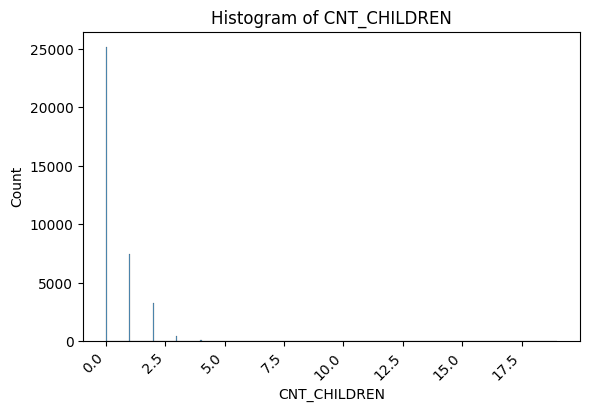

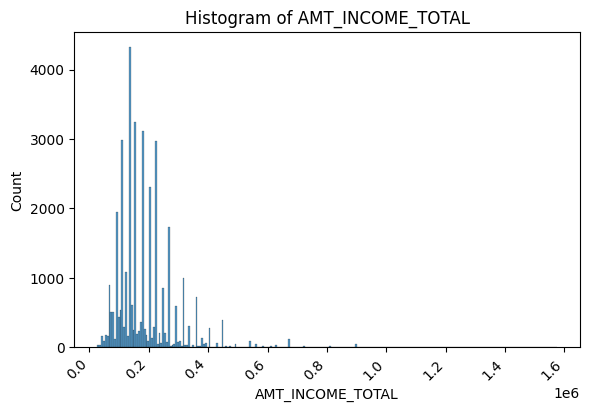

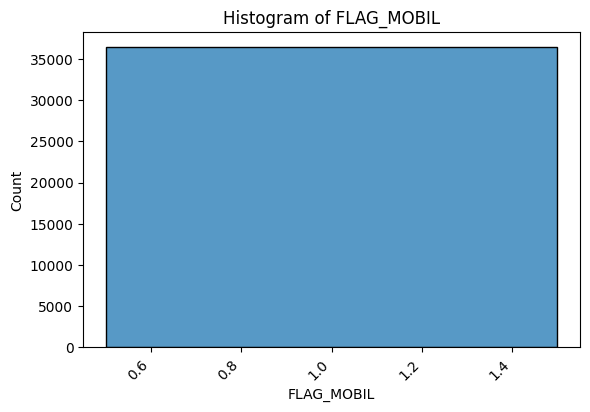

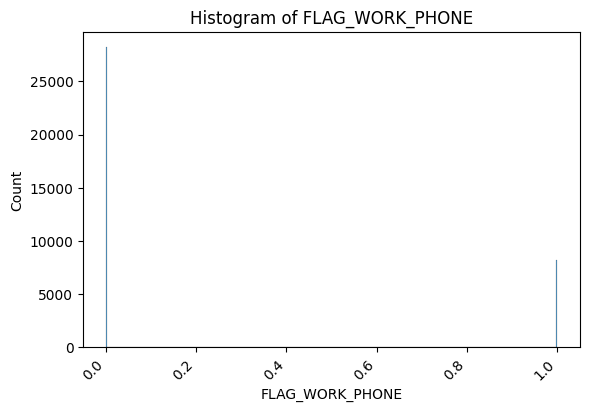

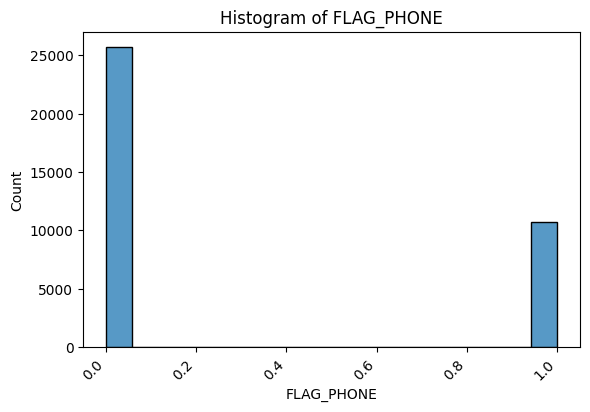

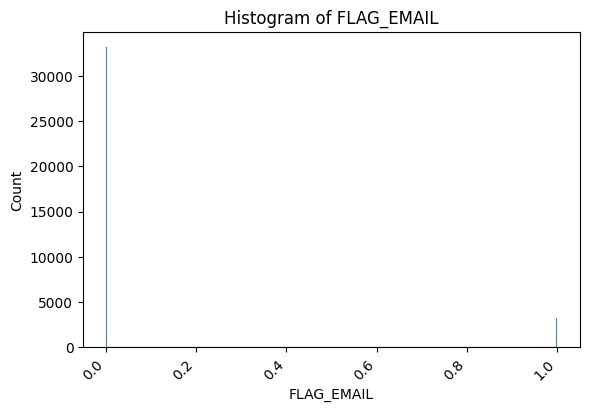

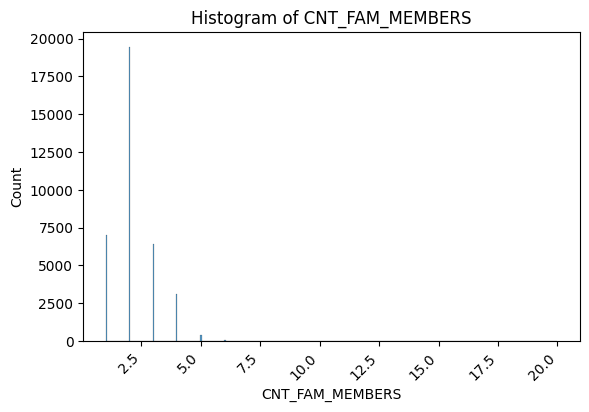

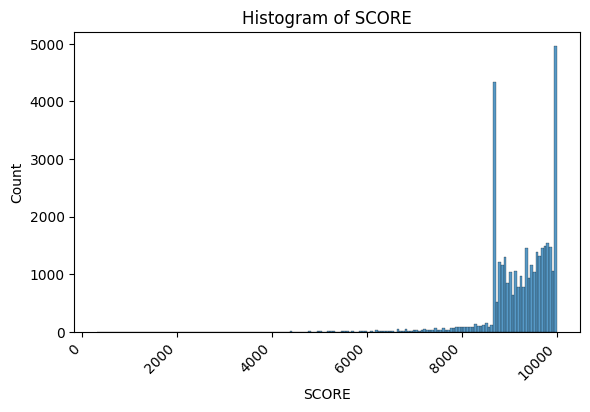

In [12]:
# Plot histograms for all numerical columns to examine their distribution
for col in df_numeric_columns[1:]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.title(f'Histogram of {col}')
    plt.show()

<br>

#### **Observation regarding `df_categorical_columns`**
- The dataset contains multiple categorical variables related to **demographics, income type, education, housing, and occupation**.
- `CODE_GENDER`, `FLAG_OWN_CAR`, and `FLAG_OWN_REALTY` are binary categorical features (Yes/No type variables).
- `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`, and `OCCUPATION_TYPE` contain **multiple categories and may have class imbalance**.
- `BIRTHDAY` and `EMPLOYED_DATE` are stored as **strings** but represent **date variables** and should be converted to datetime format.

In [13]:
# Select categorical columns (object, string, and category types)
df_categorical_columns = df.select_dtypes(include=['string', 'category']).columns.tolist()
df_categorical_columns

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'BIRTHDAY',
 'EMPLOYED_DATE',
 'OCCUPATION_TYPE']

<br>

#### **Observation regarding `df_categorical_columns` diagram**
- Several categorical variables are **imbalanced**, with one category occurring much more frequently than others.
- `CODE_GENDER` shows a higher proportion of one gender compared to the other.
- Binary variables such as `FLAG_OWN_CAR`, `FLAG_OWN_REALTY` are dominated by one class.
- Multi-category features such as income type, education, housing, occupation include some categories with very small counts.

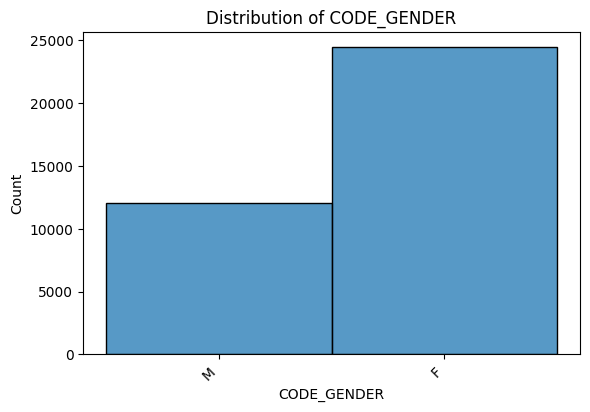

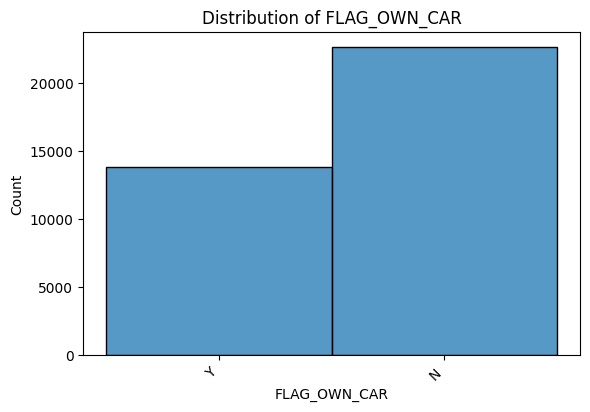

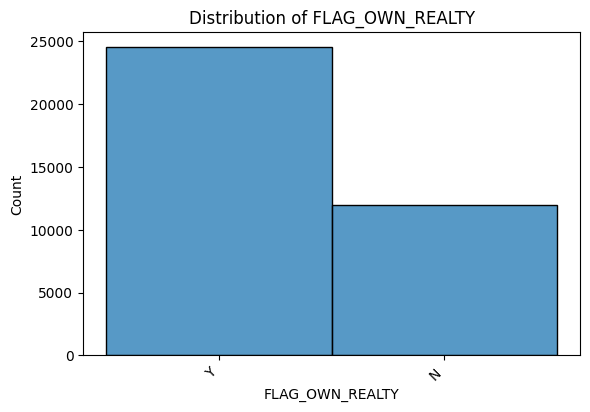

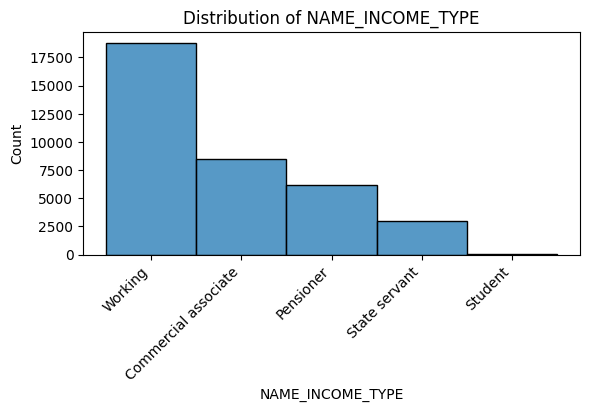

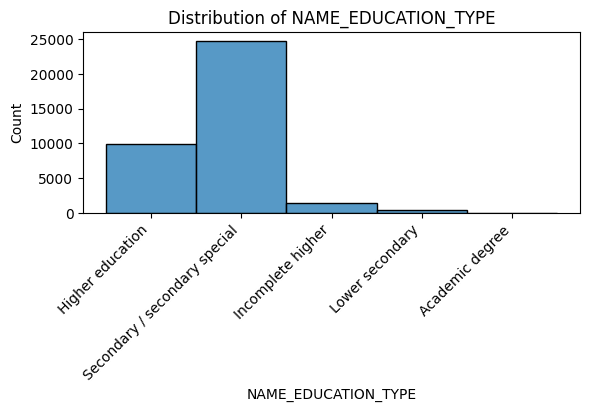

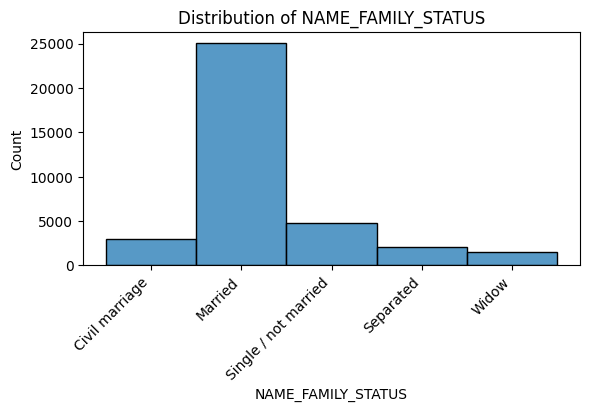

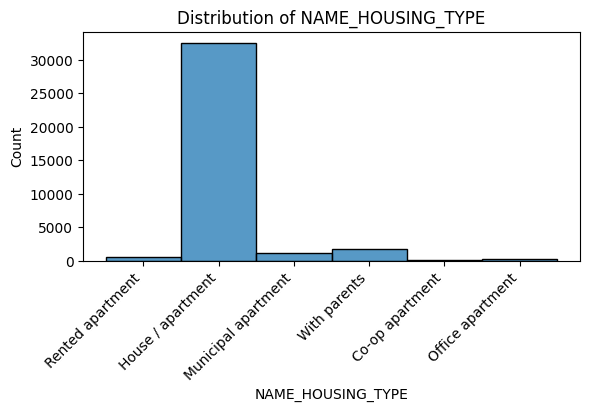

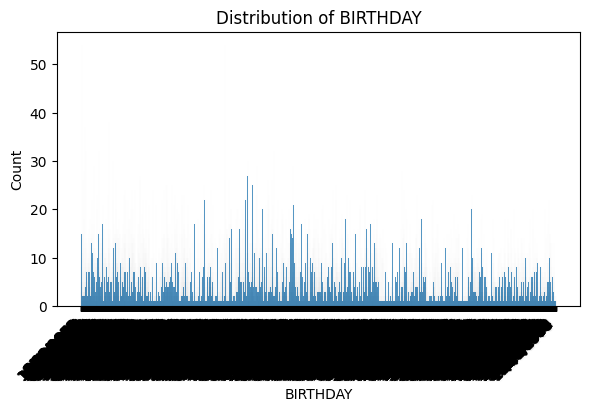

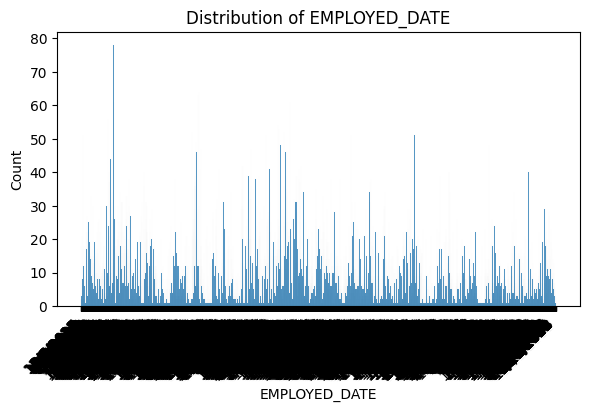

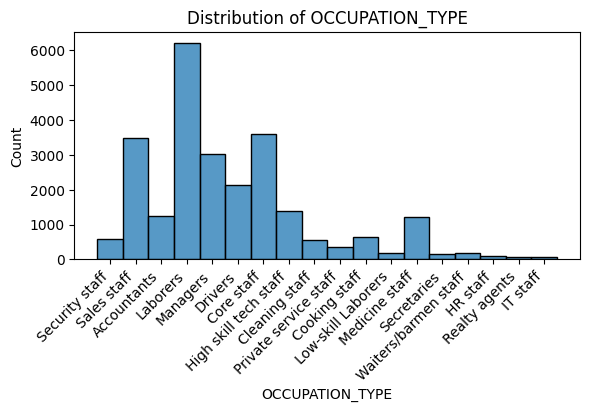

In [14]:
# Plot count distribution for all categorical columns
for col in df_categorical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=False)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.title(f'Distribution of {col}')
    plt.show()

<br>

#### **Observation regarding `sns.pairplot(df)`**
- The dataset contains a high number of **binary features**, which appear as vertical and horizontal bands in the pairwise plots.
- Continuous variables display **weak pairwise linear relationships**, with no clearly defined linear trends across feature combinations.
- Several numerical features, including `AMT_INCOME_TOTAL` and `SCORE`, show **right-skewed distributions** in the diagonal plots.
- Count-based variables such as `CNT_CHILDREN` and `CNT_FAM_MEMBERS` take **discrete integer values**, resulting in visible clustering patterns.
- The relationship between `AMT_INCOME_TOTAL` and `SCORE` appears scattered and non-linear, with no clear monotonic pattern.
- Binary flag variables exhibit **uneven class distributions**, as indicated by imbalanced histogram bars.
- No strong pairwise feature dependency or multicollinearity is visually apparent from the pairplot.

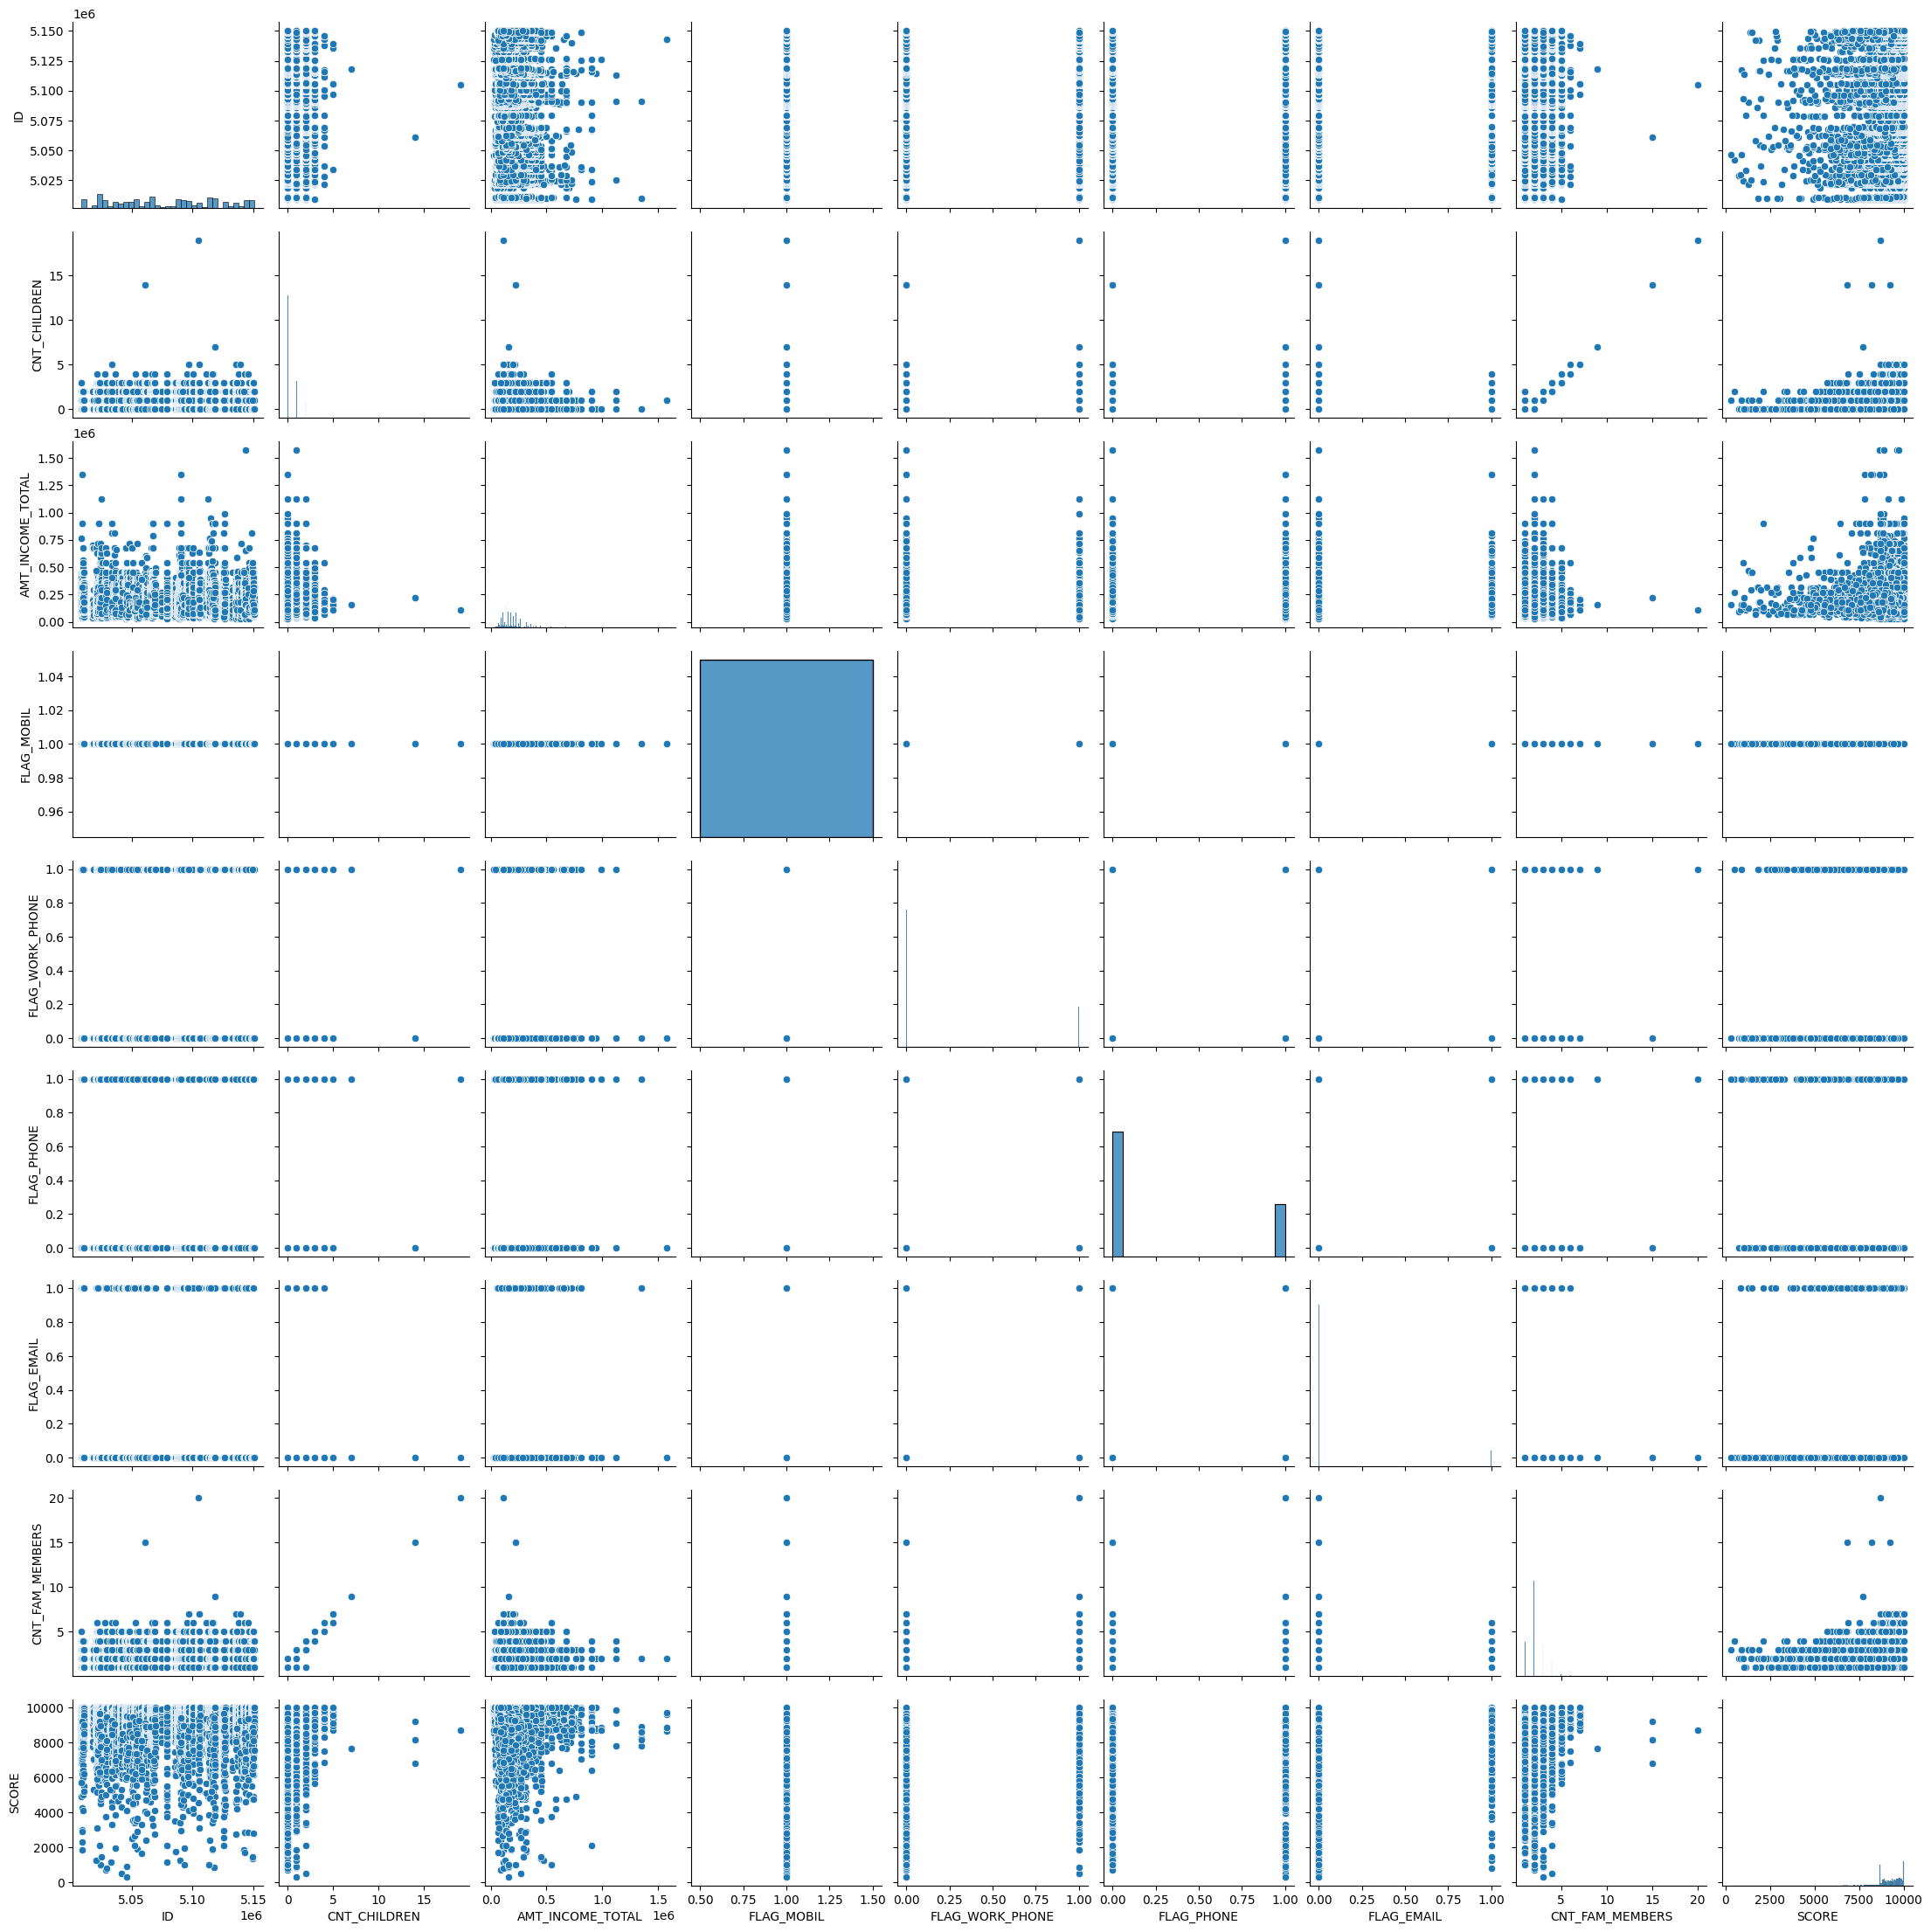

In [15]:
# Plot pairwise relationships using seaborn pairplot
sns.pairplot(df)
plt.show()

<br>

#### **Observation regarding `SCORE`**
- The `SCORE` variable shows a **non-uniform** distribution with most values concentrated in the higher score range.
- The distribution is **left-skewed**, with a long tail extending toward lower score values.
- Multiple peaks are visible, indicating that the `SCORE` values are **clustered around specific ranges** rather than being smoothly distributed.
- Very low score values occur **infrequently** compared to high score values.

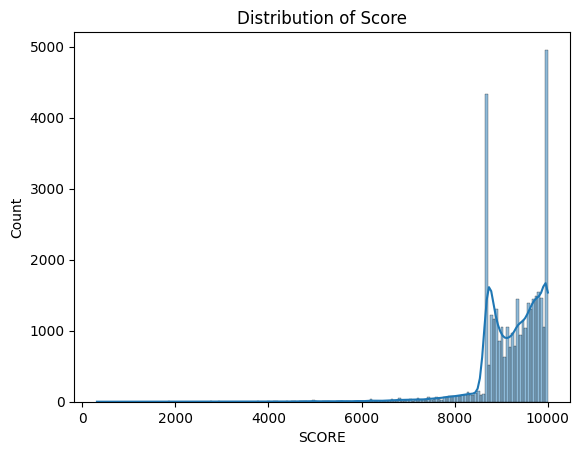

In [16]:
# Plot the distribution of the score to examine its spread, skewness, and overall shape
sns.histplot(df['SCORE'], kde=True)
plt.title('Distribution of Score')
plt.show()

<br>

#### **Observation regarding `correlation_matrix`**
- Most features show **very weak correlations**, indicating limited linear relationships.
- CNT_CHILDREN and `CNT_FAM_MEMBERS` have a **strong positive correlation (0.89)**, which is logically expected.
- `FLAG_WORK_PHONE` and `FLAG_PHONE` show a **moderate correlation (0.31)**.
- `SCORE` has **near-zero correlation** with other variables.
- `ID` has **no meaningful correlation** and should be excluded from analysis and modeling.

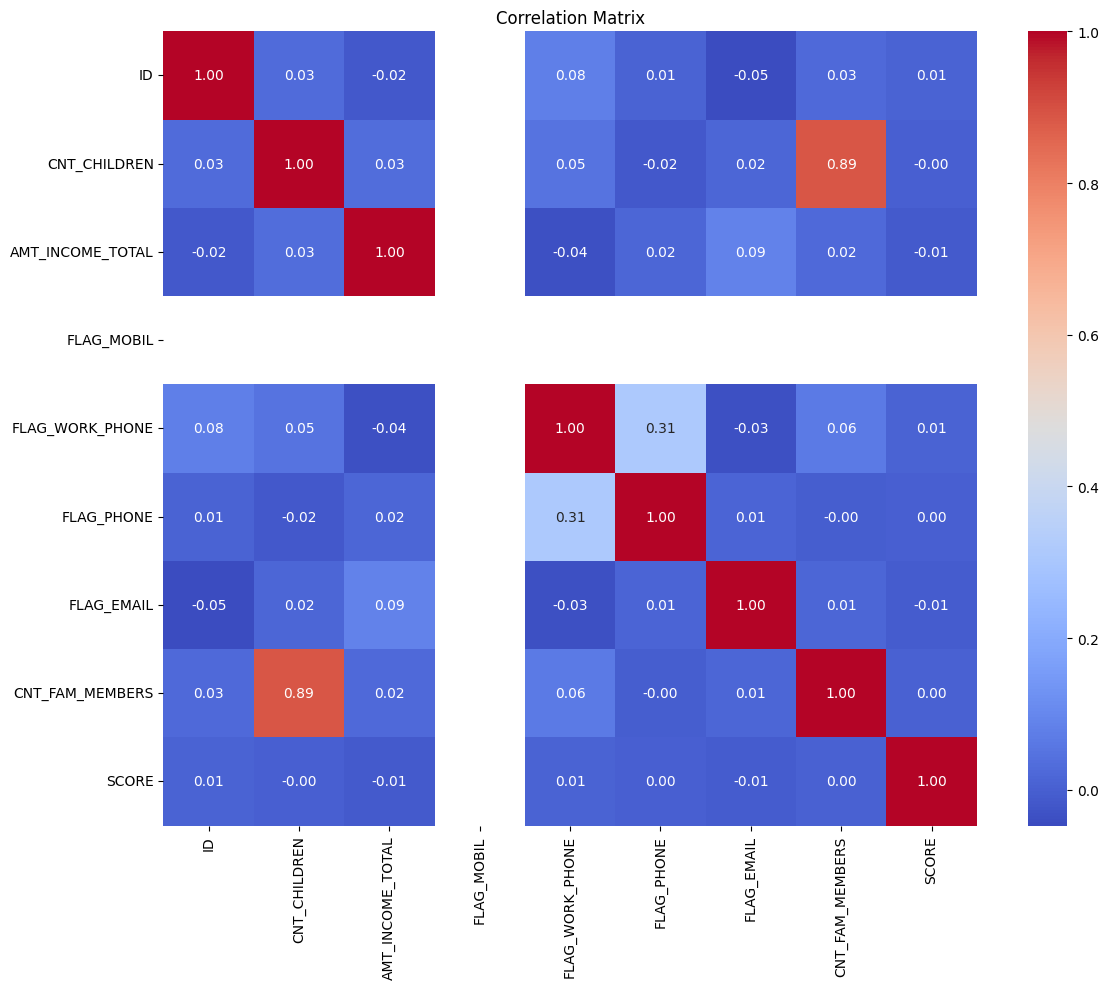

In [17]:
# Correlation Matrix
correlation_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

<br>

# II. **Data Cleaning**

#### **Observation regarding `missing values`**
- `OCCUPATION_TYPE` and `EMPLOYED_DATE` contain a noticeable amount of missing data.

In [18]:
# Check missing values
missing_values = df.isnull().sum()

# Calculate missing value percentages
missing_percentage = (missing_values / len(df)) * 100

# Display missing value summary
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
}).sort_values(by='Missing Values', ascending=False)

print(missing_df)

                     Missing Values  Percentage (%)
OCCUPATION_TYPE               11323           31.06
EMPLOYED_DATE                  6135           16.83
ID                                0            0.00
FLAG_OWN_CAR                      0            0.00
CODE_GENDER                       0            0.00
FLAG_OWN_REALTY                   0            0.00
CNT_CHILDREN                      0            0.00
NAME_EDUCATION_TYPE               0            0.00
NAME_FAMILY_STATUS                0            0.00
AMT_INCOME_TOTAL                  0            0.00
NAME_INCOME_TYPE                  0            0.00
BIRTHDAY                          0            0.00
NAME_HOUSING_TYPE                 0            0.00
FLAG_WORK_PHONE                   0            0.00
FLAG_MOBIL                        0            0.00
FLAG_PHONE                        0            0.00
FLAG_EMAIL                        0            0.00
CNT_FAM_MEMBERS                   0            0.00
SCORE       

<br>

## **2.1 Handling Duplicate Values in the Dataset**

#### **Observation regarding Checking for the `duplicated`**
- The `ID` column is removed to avoid using a unique identifier in duplicate detection.
- The output highlights rows that are **exact duplicates across all remaining columns**.

In [19]:
# Remove the ID column
df = df.drop(columns=['ID'])

In [20]:
# Identify duplicate rows
duplicates = df.duplicated()

In [21]:
# Display duplicate records
duplicates[duplicates==True]

8        True
9        True
15       True
26       True
35       True
37       True
38       True
39       True
43       True
46       True
48       True
50       True
51       True
52       True
53       True
55       True
57       True
65       True
68       True
72       True
73       True
77       True
78       True
79       True
80       True
81       True
82       True
83       True
84       True
86       True
87       True
88       True
89       True
90       True
91       True
92       True
93       True
94       True
95       True
96       True
98       True
100      True
102      True
107      True
108      True
112      True
116      True
117      True
119      True
121      True
122      True
123      True
124      True
127      True
128      True
129      True
131      True
132      True
133      True
136      True
140      True
141      True
149      True
153      True
154      True
158      True
159      True
160      True
162      True
170      True
173      True
174   

<br>

#### **Observation regarding the `before_counts`**
- The output shows the number of non-null values in each column.
- Columns with **lower** counts compared to the total number of rows contain missing values.
- If the number of values in a column **equals** the size of the dataset, it has no missing data.

In [22]:
# Count non-missing (non-null) and missing (non-null) values in each column before data cleaning
before_counts = df.count()
before_counts

CODE_GENDER            36457
FLAG_OWN_CAR           36457
FLAG_OWN_REALTY        36457
CNT_CHILDREN           36457
AMT_INCOME_TOTAL       36457
NAME_INCOME_TYPE       36457
NAME_EDUCATION_TYPE    36457
NAME_FAMILY_STATUS     36457
NAME_HOUSING_TYPE      36457
BIRTHDAY               36457
EMPLOYED_DATE          30322
FLAG_MOBIL             36457
FLAG_WORK_PHONE        36457
FLAG_PHONE             36457
FLAG_EMAIL             36457
OCCUPATION_TYPE        25134
CNT_FAM_MEMBERS        36457
SCORE                  36457
dtype: int64

<br>

#### **Observation regarding `df.duplicated()`**
- Duplicate records are removed from the dataset using `df.drop_duplicates()`.
- A subsequent duplicate check using `df.duplicated()` returns an empty result.
- This confirms that **no duplicate rows** remain in the dataset after the removal step.

In [23]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [24]:
# Confirm no duplicate records remain
duplicates = df.duplicated()
duplicates[duplicates==True]

Series([], dtype: bool)

<br>

#### **Observation regarding the `after_counts`**
- Most columns contain **27,918 non-null values**, indicating no missing data after cleaning.
- `EMPLOYED_DATE` has fewer non-null values **23,255**, meaning some missing values still exist.
- `OCCUPATION_TYPE` has fewer non-null values **19,350**, meaning some missing values still exist.

In [25]:
# Count non-missing (non-null) and missing (non-null) values in each column after data cleaning
after_counts = df.count()
after_counts

CODE_GENDER            27918
FLAG_OWN_CAR           27918
FLAG_OWN_REALTY        27918
CNT_CHILDREN           27918
AMT_INCOME_TOTAL       27918
NAME_INCOME_TYPE       27918
NAME_EDUCATION_TYPE    27918
NAME_FAMILY_STATUS     27918
NAME_HOUSING_TYPE      27918
BIRTHDAY               27918
EMPLOYED_DATE          23255
FLAG_MOBIL             27918
FLAG_WORK_PHONE        27918
FLAG_PHONE             27918
FLAG_EMAIL             27918
OCCUPATION_TYPE        19350
CNT_FAM_MEMBERS        27918
SCORE                  27918
dtype: int64

<br>

#### **Observation regarding the `duplicate` comparison**
- The dataset size reduced from **36,457 to 27,918** rows, indicating that **8,539 duplicate records** were removed.
- `EMPLOYED_DATE` decreased from **30,322 to 23,255**,  indicating that **7,067 duplicate records** were removed.
- `OCCUPATION_TYPE` decreased from **25,134 to 19,350** indicating that **5,784 duplicate records** were removed.

In [26]:
# Creat a table to compare counts before and after duplicate removal 
comparison_df = pd.DataFrame({
    'Before': before_counts,
    'After': after_counts,
    'Difference': before_counts - after_counts
}).sort_values(by='Difference', ascending=True)

print(comparison_df)

                     Before  After  Difference
OCCUPATION_TYPE       25134  19350        5784
EMPLOYED_DATE         30322  23255        7067
CODE_GENDER           36457  27918        8539
FLAG_OWN_CAR          36457  27918        8539
AMT_INCOME_TOTAL      36457  27918        8539
NAME_INCOME_TYPE      36457  27918        8539
FLAG_OWN_REALTY       36457  27918        8539
CNT_CHILDREN          36457  27918        8539
NAME_FAMILY_STATUS    36457  27918        8539
NAME_EDUCATION_TYPE   36457  27918        8539
BIRTHDAY              36457  27918        8539
NAME_HOUSING_TYPE     36457  27918        8539
FLAG_MOBIL            36457  27918        8539
FLAG_WORK_PHONE       36457  27918        8539
FLAG_PHONE            36457  27918        8539
FLAG_EMAIL            36457  27918        8539
CNT_FAM_MEMBERS       36457  27918        8539
SCORE                 36457  27918        8539


<br>

## **2.2 Handling Missing Values**

### **1. `EMPLOYED_DATE` by Creating a New Feature Called `IS_EMPLOYED`**

#### **Observation regarding `EMPLOYED_DATE`**
- Missing values in `EMPLOYED_DATE` mainly belong to **Pensioners**, indicating they are **NOT Employed**.
- A new feature `IS_EMPLOYED` was created **1 = employed, 0 = not employed**.
- The original `EMPLOYED_DATE` column was dropped to avoid redundancy.

In [27]:
# Classify applicants as employed if income type is not 'Pensioner'
df['IS_EMPLOYED'] = (df['NAME_INCOME_TYPE'] != 'Pensioner').astype(int)

In [28]:
# Validate employment status classification using cross-tabulation
pd.crosstab(df['NAME_INCOME_TYPE'], df['IS_EMPLOYED'])

IS_EMPLOYED,0,1
NAME_INCOME_TYPE,,
Commercial associate,0,6556
Pensioner,4680,0
State servant,0,2251
Student,0,11
Working,0,14420


In [29]:
# Drop column EMPLOYED_DATE
df = df.drop(columns=['EMPLOYED_DATE'])

<br>

### **2. `OCCUPATION_TYPE` by Separating into Categories**

#### **Observation regarding `OCCUPATION_TYPE`**
- `OCCUPATION_TYPE` contains multiple categories with a significant number of missing values.
- Missing values were treated as a **separate category** using one-hot encoding `dummy_na=True` **to preserve information and avoid data loss**.
- All generated dummy variables are **Boolean (True/False)** and suitable for machine learning models.

In [30]:
# Check distribution of OCCUPATION_TYPE (including missing values)
df['OCCUPATION_TYPE'].value_counts(dropna=False)

OCCUPATION_TYPE
NaN                      8568
Laborers                 4805
Core staff               2761
Sales staff              2654
Managers                 2326
Drivers                  1701
High skill tech staff    1085
Medicine staff            914
Accountants               895
Cooking staff             511
Security staff            477
Cleaning staff            443
Private service staff     248
Low-skill Laborers        135
Secretaries               123
Waiters/barmen staff      107
HR staff                   67
IT staff                   50
Realty agents              48
Name: count, dtype: int64

In [31]:
# Apply one-hot encoding and treat missing values as a separate category
df = pd.get_dummies(df, columns=['OCCUPATION_TYPE'], dummy_na=True)

In [32]:
# Verify that new dummy columns are numeric
occupation_dummy_cols = [
    col for col in df.columns if col.startswith('OCCUPATION_TYPE_')
]

df[occupation_dummy_cols].dtypes

OCCUPATION_TYPE_Accountants              bool
OCCUPATION_TYPE_Cleaning staff           bool
OCCUPATION_TYPE_Cooking staff            bool
OCCUPATION_TYPE_Core staff               bool
OCCUPATION_TYPE_Drivers                  bool
OCCUPATION_TYPE_HR staff                 bool
OCCUPATION_TYPE_High skill tech staff    bool
OCCUPATION_TYPE_IT staff                 bool
OCCUPATION_TYPE_Laborers                 bool
OCCUPATION_TYPE_Low-skill Laborers       bool
OCCUPATION_TYPE_Managers                 bool
OCCUPATION_TYPE_Medicine staff           bool
OCCUPATION_TYPE_Private service staff    bool
OCCUPATION_TYPE_Realty agents            bool
OCCUPATION_TYPE_Sales staff              bool
OCCUPATION_TYPE_Secretaries              bool
OCCUPATION_TYPE_Security staff           bool
OCCUPATION_TYPE_Waiters/barmen staff     bool
OCCUPATION_TYPE_nan                      bool
dtype: object

<br>

#### **Observation regarding missing values**
- After removing duplicate records and handling missing values, all columns now show **0 missing values**.
- The dataset is **fully cleaned** and ready for modeling or further analysis.

In [33]:
# Recheck missing values after removing duplicate records
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage.round(2)
}).sort_values(by='Missing Values', ascending=False)

print(missing_df)

                                       Missing Values  Percentage (%)
CODE_GENDER                                         0             0.0
FLAG_OWN_CAR                                        0             0.0
FLAG_OWN_REALTY                                     0             0.0
CNT_CHILDREN                                        0             0.0
AMT_INCOME_TOTAL                                    0             0.0
NAME_INCOME_TYPE                                    0             0.0
NAME_EDUCATION_TYPE                                 0             0.0
NAME_FAMILY_STATUS                                  0             0.0
NAME_HOUSING_TYPE                                   0             0.0
BIRTHDAY                                            0             0.0
FLAG_MOBIL                                          0             0.0
FLAG_WORK_PHONE                                     0             0.0
FLAG_PHONE                                          0             0.0
FLAG_EMAIL          

<br>

## **2.3 Outlier Detection and Handling**

#### **Observation regarding `outliers` | (Before Data Processing)**
- **AMT_INCOME_TOTAL** has the highest proportion of outliers **4.19%**, indicating significant income disparity.
- **SCORE** also shows notable outliers **2.19%**, suggesting the presence of some extreme values.
- **CNT_CHILDREN** and **CNT_FAM_MEMBERS** have a small percentage of outliers **~1.3%**, likely due to unusually large household sizes.

In [34]:
# Calculate IQR-based outlier summary for all numeric columns in a DataFrame
def iqr_outlier_summary_all_numeric(df, exclude_cols=None):
    # Convert excluded columns to a set
    exclude_cols = set(exclude_cols or [])

    # Total number of rows in the dataset
    total_rows = len(df)

    # Select numeric columns
    numeric_cols = df.select_dtypes(include='number').columns

    # Store results for each numeric column
    rows = []

    for col in numeric_cols:
        # Skip excluded columns
        if col in exclude_cols:
            continue

        # Remove missing values for calculation
        s = df[col].dropna()

        # Column has no valid values
        if s.empty:
            rows.append({
                'feature': col,
                'outliers_count': 0,
                'outliers_pct': 0.0,
                'lower_bound': np.nan,
                'upper_bound': np.nan
            })
            continue

        # Calculate Q1, Q3, and IQR
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        # Column has constant values)
        if iqr == 0:
            rows.append({
                'feature': col,
                'outliers_count': 0,
                'outliers_pct': 0.0,
                'lower_bound': np.nan,
                'upper_bound': np.nan
            })
            continue

        # Define lower and upper bounds using IQR method
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # Count outliers
        outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()

        # Append results
        rows.append({
            'feature': col,
            'outliers_count': int(outliers_count),
            'outliers_pct': round((outliers_count / total_rows) * 100, 2),
            'lower_bound': round(lower, 2),
            'upper_bound': round(upper, 2)
        })

    # Return sorted summary DataFrame
    return (pd.DataFrame(rows)
            .sort_values('outliers_count', ascending=False)
            .reset_index(drop=True))


# Apply function to dataframe
numeric_outliers = iqr_outlier_summary_all_numeric(df)

# Display result
numeric_outliers

,feature,outliers_count,outliers_pct,lower_bound,upper_bound
0,AMT_INCOME_TOTAL,1159,4.15,-33750.0,380250.0
1,SCORE,752,2.69,7511.0,11079.0
2,CNT_CHILDREN,416,1.49,-1.5,2.5
3,CNT_FAM_MEMBERS,400,1.43,0.5,4.5
4,FLAG_MOBIL,0,0.00,NaN,NaN
5,FLAG_PHONE,0,0.00,-1.5,2.5
6,FLAG_WORK_PHONE,0,0.00,NaN,NaN
7,FLAG_EMAIL,0,0.00,NaN,NaN
8,IS_EMPLOYED,0,0.00,NaN,NaN


<br>

#### **Observation regarding `outliers` diagram | (Before Data Processing)**
- Several numeric features show extreme values beyond the whiskers in the boxplots.
- `AMT_INCOME_TOTAL` and `SCORE` display noticeable right-skewness with high-value outliers.
- `CNT_CHILDREN` and `CNT_FAM_MEMBERS` show some unusual high counts.

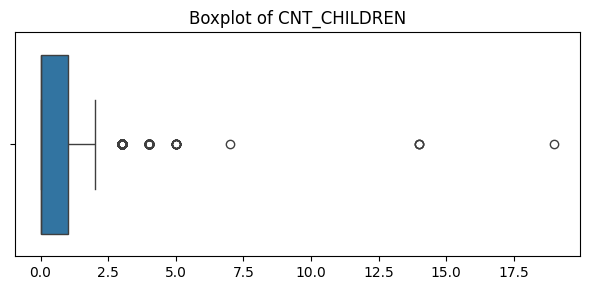

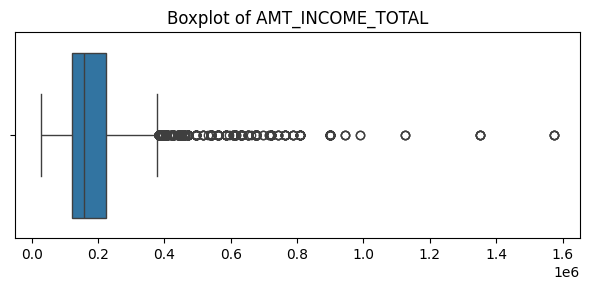

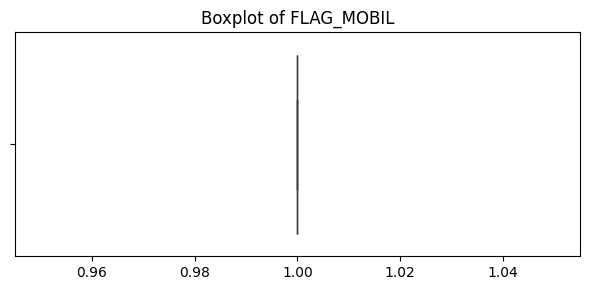

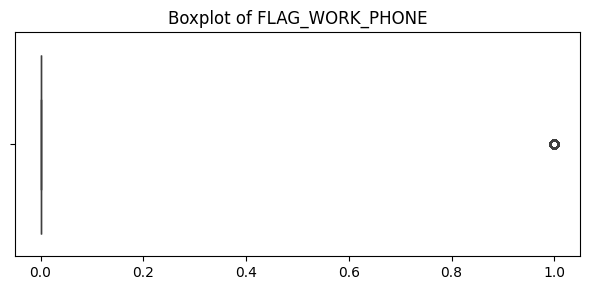

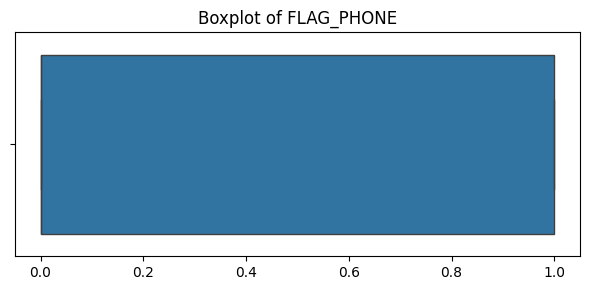

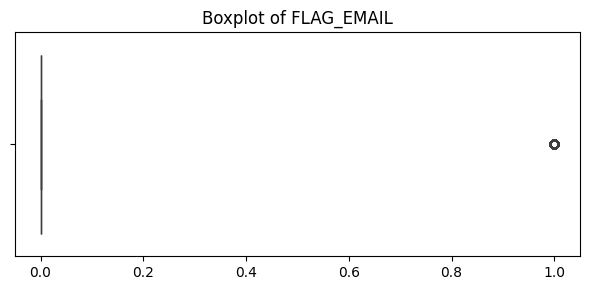

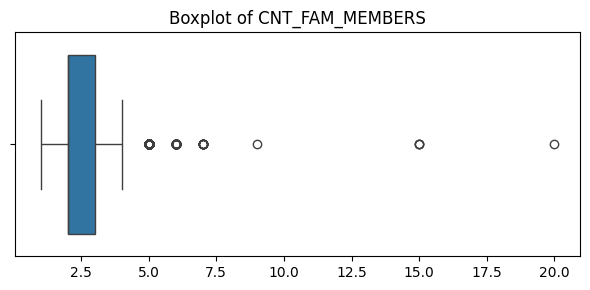

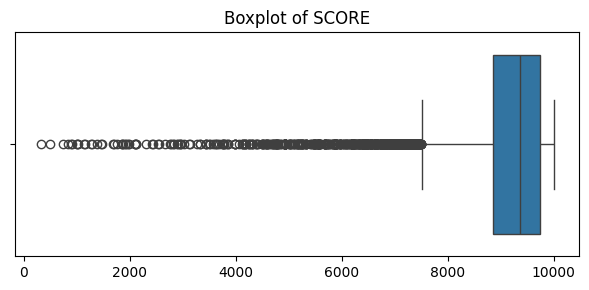

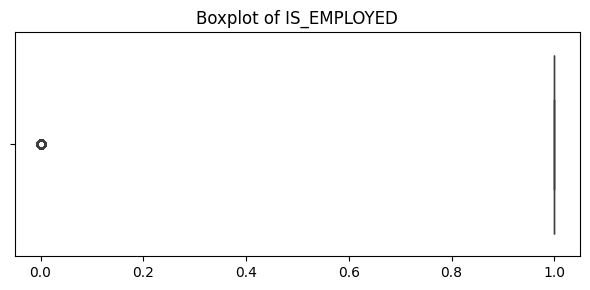

In [35]:
# Generate boxplots for all numeric columns to visualize potential outliers
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x=column)
    plt.title(f'Boxplot of {column}')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

<br>

#### **Observation regarding `outliers` | (After Data Processing)**
- Extreme values in numeric columns were capped using the **IQR method**.
- After capping, **outliers are removed**, indicating the data is now less affected by extreme values.

In [36]:
# Applying Winsorization using IQR
def cap_outliers_iqr_all_numeric(df):

    # Select numeric columns
    numeric_columns = df.select_dtypes(include='number').columns

    # Loop through each numeric column
    for col in numeric_columns:

        # Remove missing values for IQR calculation
        series = df[col].dropna()

        # Skip column if empty
        if series.empty:
            continue

        # Calculate Q1 and Q3
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        # Compute IQR
        iqr = q3 - q1

        # Skip if constant column
        if iqr == 0:
            continue

        # Define lower and upper bounds
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Cap extreme values directly in original dataframe
        df[col] = df[col].clip(lower_bound, upper_bound)

    return df

# Apply IQR-based winsorization
df = cap_outliers_iqr_all_numeric(df)

# Recalculate outlier summary
outliers_after = iqr_outlier_summary_all_numeric(df)

# Display result
outliers_after

,feature,outliers_count,outliers_pct,lower_bound,upper_bound
0,CNT_CHILDREN,0,0.0,-1.5,2.5
1,AMT_INCOME_TOTAL,0,0.0,-33750.0,380250.0
2,FLAG_MOBIL,0,0.0,NaN,NaN
3,FLAG_WORK_PHONE,0,0.0,NaN,NaN
4,FLAG_PHONE,0,0.0,-1.5,2.5
5,FLAG_EMAIL,0,0.0,NaN,NaN
6,CNT_FAM_MEMBERS,0,0.0,0.5,4.5
7,SCORE,0,0.0,7511.0,11079.0
8,IS_EMPLOYED,0,0.0,NaN,NaN


<br>

#### **Observation regarding `outliers` diagram | (After Data Processing)**
- Boxplots show **no visible outliers** beyond the whiskers.
- The distribution appears more compact and stable.
- The influence of extreme values on modeling is reduced.

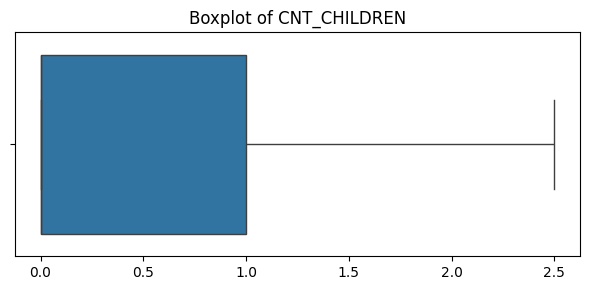

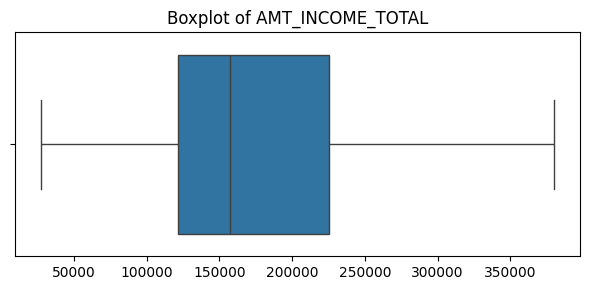

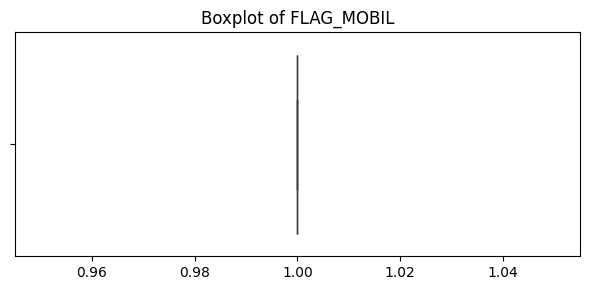

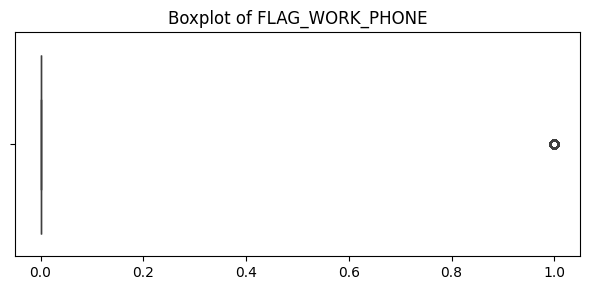

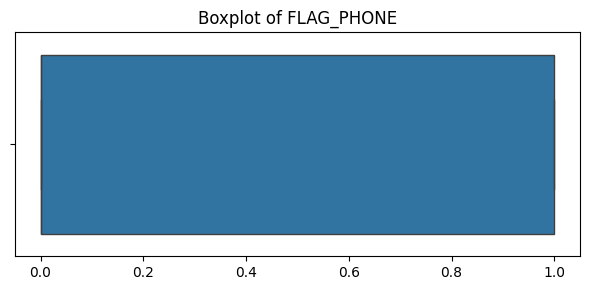

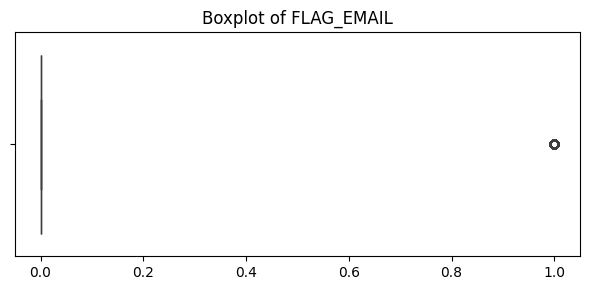

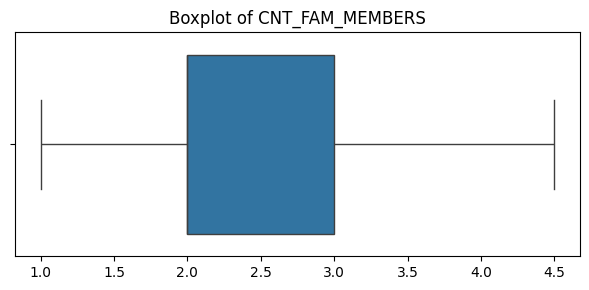

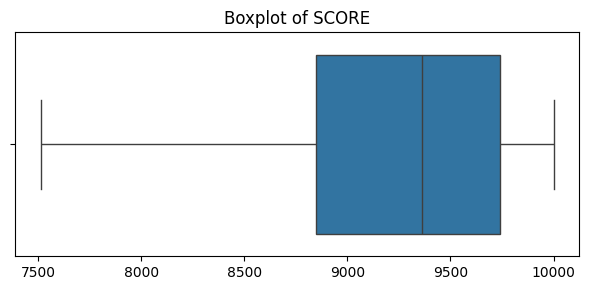

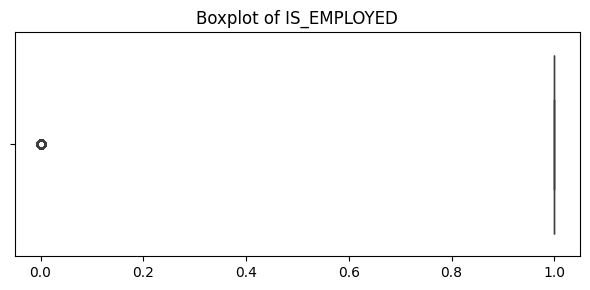

In [37]:
# Generate boxplots for all numeric columns to visualize potential outliers
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=df, x=column)
    plt.title(f'Boxplot of {column}')
    plt.xlabel('')
    plt.tight_layout()
    plt.show()

<br>

# III. **Feature Engineering**

## **3.1 Create a New Feature by Converting `BIRTHDAY` to `AGE`**

#### **Observation regarding `AGE`**
- The **average** customer age is approximately **43** years.
- **50%** of customers are between **34 and 53** years old.
- The **youngest** customer is **20** years old.
- The **oldest** customer is **68** years old.
- The **standard deviation** is **11.5**, indicating a moderate age spread across customers.

In [38]:
# Convert BIRTHDAY column to datetime format
df['BIRTHDAY'] = pd.to_datetime(df['BIRTHDAY'], errors='coerce')

In [39]:
# Calculate AGE in years
today = pd.Timestamp.today()
df['AGE'] = (today - df['BIRTHDAY']).dt.days // 365

In [40]:
# Drop BIRTHDAY column
df.drop(columns=['BIRTHDAY'], inplace=True)

<br>

#### **Observation regarding `df[['AGE']].head()`**
- The `AGE` column has been successfully created from the BIRTHDAY feature.
- The values appear as **integer numbers** representing age in years.

In [41]:
# Preview AGE column
df[['AGE']].head()

,AGE
0,33
1,33
2,58
3,52
4,52


<br>

#### **Observation regarding `df[['AGE']].describe()`**
- **The average age is approximately 43 years**.
- **The minimum age is 20 years and the maximum is 69 years**, indicating a reasonable adult age range.

In [42]:
# Summary statistics of AGE
df['AGE'].describe().round(4)

count    27918.0000
mean        43.4389
std         11.5152
min         20.0000
25%         34.0000
50%         42.0000
75%         53.0000
max         69.0000
Name: AGE, dtype: float64

<br>

#### **Observation regarding `df[['AGE', 'SCORE']].corr()`**
- The correlation between AGE and SCORE is approximately **0.02**, which is extremely close to zero.
- This indicates **no significant linear relationship** between age and score.
- **Age** does not appear to be a **strong predictor** of score in this dataset.**

In [43]:
# Compute correlation
df[['AGE', 'SCORE']].corr()

,AGE,SCORE
AGE,1.000000,0.020713
SCORE,0.020713,1.000000


<br>

#### **Observation regarding `Age vs Score Scatter Plot`**
- The scatter plot shows a **widely dispersed pattern with no clear upward or downward trend**.
- Points appear randomly distributed, indicating a **very weak or no linear relationship**.

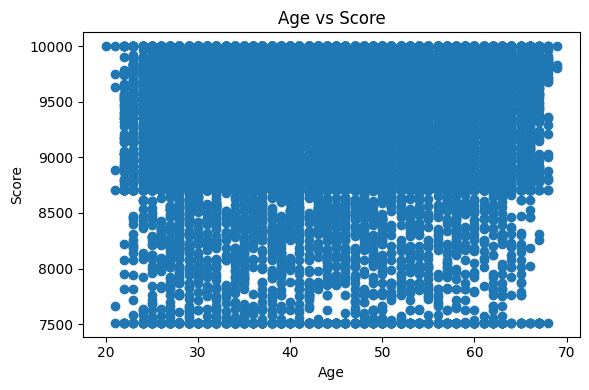

In [44]:
# Scatter plot to visualize the relationship between AGE and SCORE
plt.figure(figsize=(6, 4))
plt.scatter(df['AGE'], df['SCORE'])
plt.xlabel('Age')
plt.ylabel('Score')
plt.title('Age vs Score')
plt.tight_layout()
plt.show()

<br>

#### **Observation regarding `AGE_GROUP`**
- Customers are divided into **10 quantile-based age groups**, each containing a similar number of customers.
- Most groups contain about **2,300–3,200 customers**, showing a **balanced age distribution**
- The **46–51 age group** has the highest number of customers, indicating a strong **middle-aged segment**.
- Slightly fewer customers appear in the **older age groups (55–69)**.
- The **average SCORE** varies only slightly across age groups, suggesting a **weak relationship** between **age** and **score**.
- **Customer scores** remain relatively **consistent** across **ages**.

In [45]:
# Create 10 quantile-based age groups from the AGE column
df['AGE_GROUP'] = pd.qcut(df['AGE'], q=10)

In [46]:
# Convert age bin and display them sorted for each age group
df['AGE_GROUP'] = df['AGE_GROUP'].apply(lambda x: f'{int(x.left)} - {int(x.right)}')
df['AGE_GROUP'].value_counts().sort_index()

AGE_GROUP
19 - 28    2937
28 - 32    3022
32 - 36    3032
36 - 39    2560
39 - 42    2496
42 - 46    2812
46 - 51    3231
51 - 55    2402
55 - 60    3027
60 - 69    2399
Name: count, dtype: int64

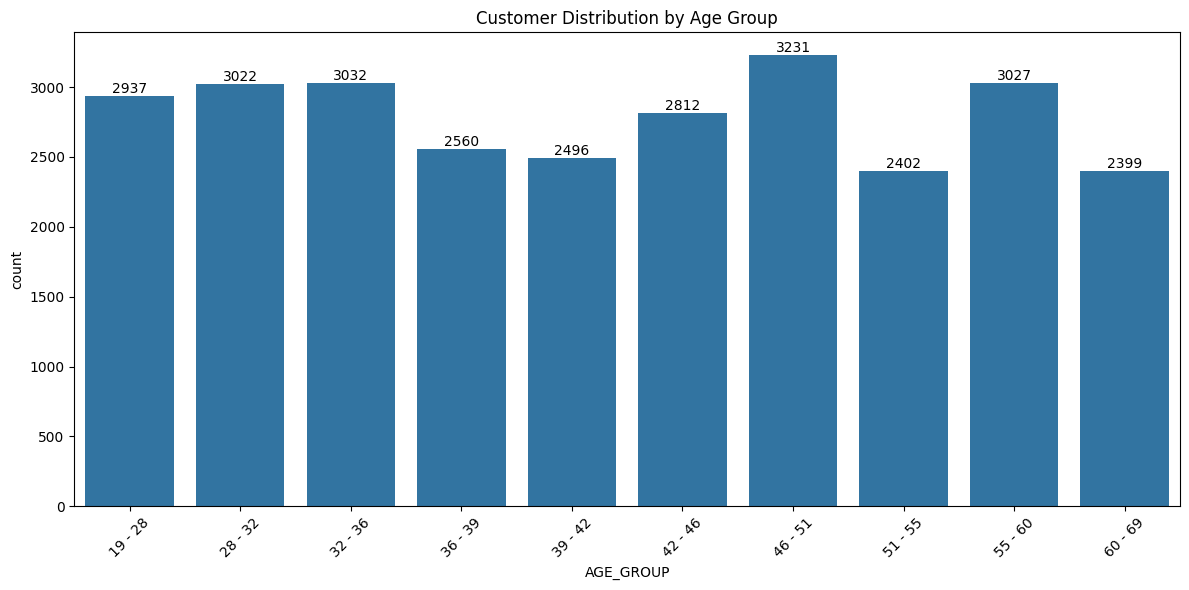

In [47]:
# Histplot to visualize the customers in each age
plt.figure(figsize=(12,6))

ax = sns.countplot(x='AGE_GROUP', data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)
plt.title('Customer Distribution by Age Group')

plt.tight_layout()
plt.show()

In [48]:
# Calculate the average SCORE for each age group
df.groupby('AGE_GROUP', observed=False)['SCORE'].mean().round(2)

AGE_GROUP
19 - 28    9210.87
28 - 32    9276.92
32 - 36    9276.23
36 - 39    9284.84
39 - 42    9289.57
42 - 46    9281.32
46 - 51    9247.57
51 - 55    9275.85
55 - 60    9268.90
60 - 69    9301.41
Name: SCORE, dtype: float64

In [49]:
# Drop AGE columns
df.drop(columns=['AGE'], inplace=True)

<br>

## **3.2 Drop Low-Variance Columns**

#### **Observation regarding `Low-Variance Columns`**
- These columns contain mostly binary values with little variability.
- Removing them helps reduce noise and unnecessary dimensionality in the dataset.

In [50]:
# Drop low-variance columns
df.drop(columns=[
    'FLAG_MOBIL',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'FLAG_EMAIL'
], inplace=True)

In [51]:
df.columns

Index(['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'CNT_FAM_MEMBERS', 'SCORE',
       'IS_EMPLOYED', 'OCCUPATION_TYPE_Accountants',
       'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_TYPE_Cooking staff',
       'OCCUPATION_TYPE_Core staff', 'OCCUPATION_TYPE_Drivers',
       'OCCUPATION_TYPE_HR staff', 'OCCUPATION_TYPE_High skill tech staff',
       'OCCUPATION_TYPE_IT staff', 'OCCUPATION_TYPE_Laborers',
       'OCCUPATION_TYPE_Low-skill Laborers', 'OCCUPATION_TYPE_Managers',
       'OCCUPATION_TYPE_Medicine staff',
       'OCCUPATION_TYPE_Private service staff',
       'OCCUPATION_TYPE_Realty agents', 'OCCUPATION_TYPE_Sales staff',
       'OCCUPATION_TYPE_Secretaries', 'OCCUPATION_TYPE_Security staff',
       'OCCUPATION_TYPE_Waiters/barmen staff', 'OCCUPATION_TYPE_nan',
       'AGE_GROUP'],
      dtype='str')

<br>

## **3.3 Data Encoding & Feature Preparation**

#### **Observation regarding `Data Encoding`**
- Categorical variables such as `gender, car ownership,` and `real estate ownership` were successfully converted into **binary numeric values (0 and 1)**.
- Remaining categorical features were transformed using **one-hot encoding**.
- The dataset is now **fully numeric** and ready for machine learning or further analysis.

In [52]:
# Convert gender values from categorical (M/F) to numeric (1/0)
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 1, 'F': 0})

# Convert car ownership flag from categorical (Y/N) to numeric (1/0)
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y': 1, 'N': 0})

# Convert real estate ownership flag from categorical (Y/N) to numeric (1/0)
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'Y': 1, 'N': 0})

In [53]:
# Convert remaining categorical variables into one-hot encoded variables
df = pd.get_dummies(df, drop_first=True)

In [54]:
# Display first 5 rows to verify
df.head()

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,SCORE,IS_EMPLOYED,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,OCCUPATION_TYPE_nan,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,AGE_GROUP_28 - 32,AGE_GROUP_32 - 36,AGE_GROUP_36 - 39,AGE_GROUP_39 - 42,AGE_GROUP_42 - 46,AGE_GROUP_46 - 51,AGE_GROUP_51 - 55,AGE_GROUP_55 - 60,AGE_GROUP_60 - 69
0,1,1,1,0.0,380250.0,2.0,9367,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False
1,1,1,1,0.0,380250.0,2.0,9325,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False
2,1,1,1,0.0,112500.0,2.0,9698,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
3,0,0,1,0.0,270000.0,1.0,9482,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False
4,0,0,1,0.0,270000.0,1.0,10000,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False


<br>

#### **Observation regarding `SCORE Distribution`**
- **Most scores** are concentrated between **`8500 and 10000`**.
- The distribution is **left-skewed**.
- The **median `9353`** is **higher than** the **mean `9247`**, confirming the **skewness**.

In [55]:
# Display descriptive statistics for the SCORE column rounded to 2 decimals
print('SCORE Summary:')
print(df['SCORE'].describe().round(2))

SCORE Summary:
count    27918.00
mean      9269.94
std        580.76
min       7511.00
25%       8849.00
50%       9360.00
75%       9741.00
max      10000.00
Name: SCORE, dtype: float64


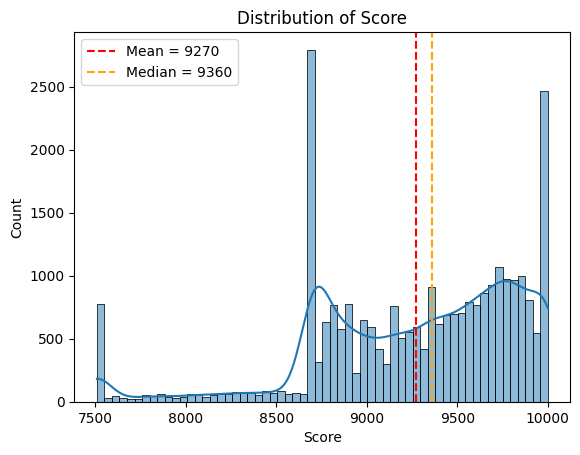

In [56]:
# Histplot to visualize the SCORE
sns.histplot(df['SCORE'], bins=60, kde=True)

plt.axvline(df['SCORE'].mean(), color='red', linestyle='--', label=f'Mean = {df['SCORE'].mean():.0f}')
plt.axvline(df['SCORE'].median(), color='orange', linestyle='--', label=f'Median = {df['SCORE'].median():.0f}')

plt.title('Distribution of Score')
plt.xlabel('Score')
plt.ylabel('Count')
plt.legend()
plt.show()

<br>

#### **Observation regarding `Dataset Saving`**
- The cleaned dataset has been successfully saved as **`Cleaned_AC_Capstone_topic_2.csv`**.
- The first few rows confirm that all preprocessing steps such as feature engineering, outlier handling, and column removal have been applied correctly.
- The dataset is now ready for modeling or further analysis.

In [57]:
# Save cleaned dataset to CSV file
df.to_csv('Cleaned_AC_Capstone_topic_2.csv', index=False)

<br>

# **Model Preparation: Feature/Target Split**

#### **Observation regarding `Model Preparation`**
- The dataset was divided into **training (80%) and testing (20%) sets** to evaluate models performance.
- Feature scaling was applied using **StandardScaler** to normalize the feature values.
- A **Linear Regression model** was trained using the scaled training data to predict the score.

In [58]:
# Define target variable
y = df['SCORE']

# Define feature variables
X = df.drop(columns=['SCORE'])

In [59]:
# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [60]:
# Initialize the StandardScaler and apply feature scaling to training and test data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
# Initialize the Linear Regression model and train the model using scaled training data
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


<br>

# **Model 1: Multiple Linear Regression Model**

#### **Observation regarding `Multiple Linear Regression Model`**
- The model predicts `scores` using **multiple features** from the dataset.
- `R²` shows how **well the model explains the variation** in `scores`.
- `RMSE` and `MAE` indicate the **prediction error** of the model.
- `Adjusted R²` evaluates **the model's performance** considering the number of features.
- Feature `coefficients` **show which variables have the most impact on the predicted `score`**.
- The graph comparing `Actual and Predicted` values shows **how closely the model's predictions match the *real values***.
- The `residual distribution` helps **verify whether the prediction errors are *randomly* distributed**.

## **1.1 Evaluate the Linear Regression (R², RMSE, and MAE)**

In [62]:
# Generate predictions using the trained Linear Regression model
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Display model performance results
print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")
print(f"MAE      : {mae:.2f}")

R² Score : 0.0036
RMSE     : 577.03
MAE      : 466.58


<br>

## **1.2 Calculate Adjusted R² for Linear Regression**

In [63]:
# Calculate Adjusted R² to evaluate model performance
n = X_test.shape[0]
p = X_test.shape[1]

# Compute Adjusted R²
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Display Adjusted R² score
print('Adjusted R²:', adjusted_r2)

Adjusted R²: -0.005805744944751501


<br>

## **1.3 Linear Regression Feature Importance (Coefficients)**

In [64]:
# Display feature coefficients to identify the most influential variables
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
3,CNT_CHILDREN,183.380242
51,AGE_GROUP_60 - 69,26.233529
45,AGE_GROUP_36 - 39,20.342303
47,AGE_GROUP_42 - 46,19.657995
46,AGE_GROUP_39 - 42,19.391875
44,AGE_GROUP_32 - 36,19.152498
50,AGE_GROUP_55 - 60,17.562779
43,AGE_GROUP_28 - 32,16.683644
49,AGE_GROUP_51 - 55,15.219349
1,FLAG_OWN_CAR,12.556671


<br>

## **1.4 Linear Regression — Actual vs Predicted Visualization**

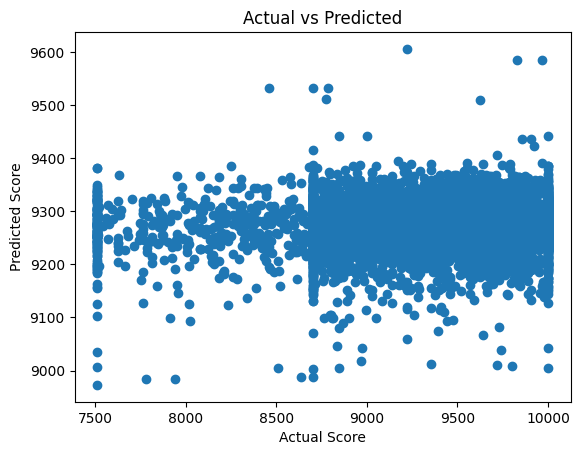

In [65]:
# Scatter plot to visualize the relationship between actual vs predicted values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted')
plt.show()

<br>

## **1.5 Linear Regression — Residual Distribution**

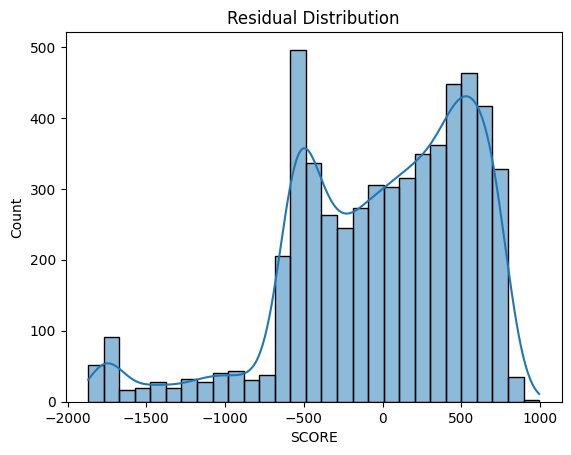

In [66]:
# Calculate residuals and visualize the distribution
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')
plt.show()

<br>

## **1.6 Linear Regression — Residuals vs Predicted Plot**

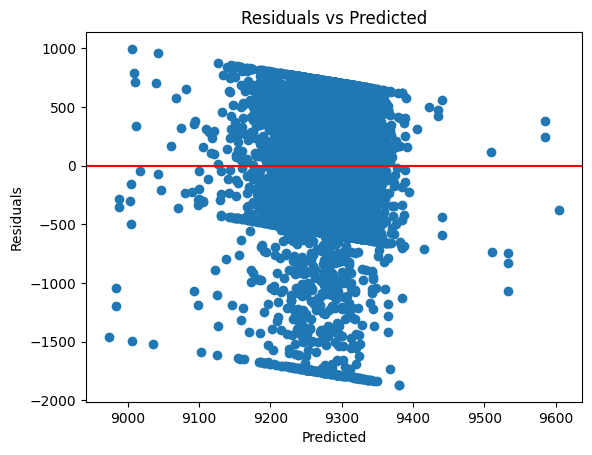

In [67]:
# Scatter plot to visualize the relationship between residuals vs predicted values
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

<br>

# **Model 2: Decision Tree Regressor**

#### **Observation regarding `Decision Tree Regressor`**
- The Decision Tree model shows **very low predictive performance**, with a **test R² of -0.0038**, indicating `the model does not explain the variance in scores well`.
- The **RMSE (~579)** suggests the model’s predictions deviate from the actual scores by about **579 points on average**.
- Cross-validation results (**CV R² = -0.0141**) confirm that the model performs **consistently poorly across different data splits**.
- `The most influential features in predicting score are` **AGE, AMT_INCOME_TOTAL, and CNT_FAM_MEMBERS**
- The trained decision tree reached a **depth of 10 with 184 leaf nodes**, indicating a moderately complex tree structure.

## **2.1 Train the Decision Tree Regressor**

In [68]:
# Initialize the Decision Tree Regressor
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    min_samples_split=20,
    random_state=42
)

# Train the Decision Tree model
dt.fit(X_train, y_train)

# Display basic tree information
print('Decision Tree training complete!')
print(f'Tree depth: {dt.get_depth()}')
print(f'Leaf nodes: {dt.get_n_leaves()}')

Decision Tree training complete!
Tree depth: 10
Leaf nodes: 162


<br>

## **2.2 Evaluate the Decision Tree (R² and RMSE)**

In [69]:
# Generate predictions for the training and testing datasets
y_pred_dt_train = dt.predict(X_train)
y_pred_dt_test = dt.predict(X_test)

# Calculate R² scores
dt_r2_train = r2_score(y_train, y_pred_dt_train)
dt_r2_test = r2_score(y_test, y_pred_dt_test)

# Calculate RMSE values
dt_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_dt_train))
dt_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_dt_test))

# Perform 5-fold cross-validation using R²
dt_cv_r2 = cross_val_score(dt, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

# Perform 5-fold cross-validation using RMSE
dt_cv_rmse = cross_val_score(
    dt,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convert negative RMSE values to positive
dt_cv_rmse = -dt_cv_rmse

# Display model performance summary
print('=' * 55)
print('        DECISION TREE — PERFORMANCE SUMMARY')
print('=' * 55)
print(f'{'Metric':<20}{'Train':>15}{'Test':>15}')
print('-' * 55)
print(f'{'R²':<20}{dt_r2_train:>15.4f}{dt_r2_test:>15.4f}')
print(f'{'RMSE':<20}{dt_rmse_train:>15.2f}{dt_rmse_test:>15.2f}')
print('=' * 55)

# Display cross-validation results
print(f'5-Fold CV R²: {dt_cv_r2.mean():.4f} ± {dt_cv_r2.std():.4f}')
print(f'5-Fold CV RMSE: {dt_cv_rmse.mean():.2f} ± {dt_cv_rmse.std():.2f}')

        DECISION TREE — PERFORMANCE SUMMARY
Metric                        Train           Test
-------------------------------------------------------
R²                           0.0325        -0.0058
RMSE                         571.86         579.75
5-Fold CV R²: -0.0162 ± 0.0034
5-Fold CV RMSE: 586.04 ± 5.37


<br>

## **2.3 Decision Tree Diagnostic Plots**

In [70]:
# Create diagnostic plots for the Decision Tree model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [71]:
# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_dt_test, alpha=0.25, s=8, color='darkorange')
rng = [y_test.min(), y_test.max()]
axes[0].plot(rng, rng, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Decision Tree\nActual vs Predicted (Test R² = {dt_r2_test:.4f})')
axes[0].legend(fontsize=9)

In [72]:
# 2. Residual distribution
dt_residuals = y_test - y_pred_dt_test
axes[1].hist(dt_residuals, bins=60, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(
    f'Residual Distribution — Decision Tree\n'
    f'Mean = {dt_residuals.mean():.1f} | Std = {dt_residuals.std():.1f}'
)

Text(0.5, 1.0, 'Residual Distribution — Decision Tree\nMean = -8.8 | Std = 579.7')

In [73]:
# 3. Residuals vs Predicted
axes[2].scatter(y_pred_dt_test, dt_residuals, alpha=0.25, s=8, color='darkorange')
axes[2].axhline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_xlabel('Predicted Score')
axes[2].set_ylabel('Residual')
axes[2].set_title('Decision Tree — Residuals vs Predicted')

Text(0.5, 1.0, 'Decision Tree — Residuals vs Predicted')

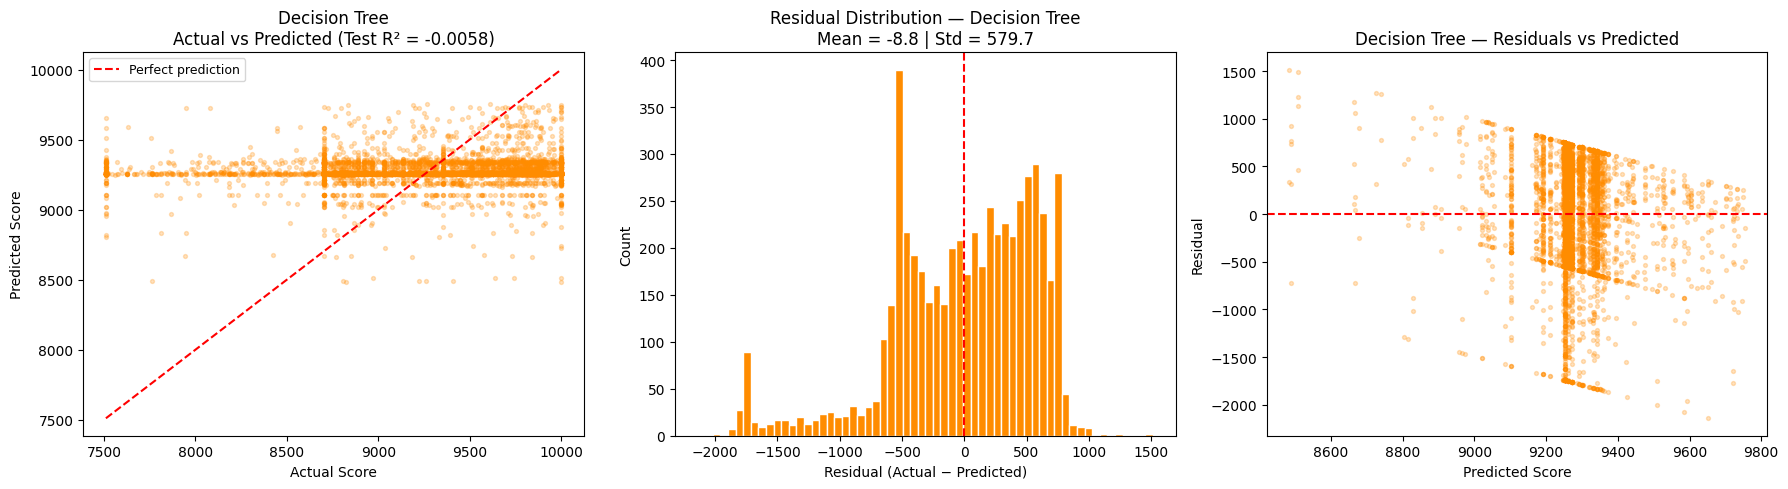

In [74]:
# Display the plots
plt.tight_layout()
plt.show()

<br>

## **2.4 Decision Tree Feature Importances**

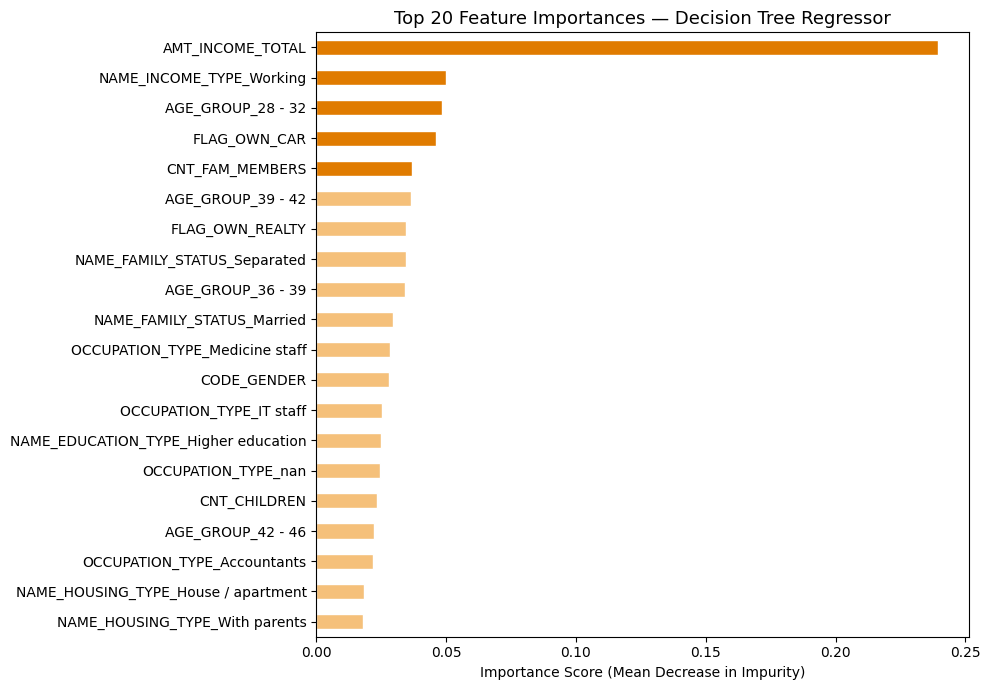

Top 10 features (Decision Tree):
AMT_INCOME_TOTAL                0.2396
NAME_INCOME_TYPE_Working        0.0498
AGE_GROUP_28 - 32               0.0483
FLAG_OWN_CAR                    0.0459
CNT_FAM_MEMBERS                 0.0369
AGE_GROUP_39 - 42               0.0364
FLAG_OWN_REALTY                 0.0346
NAME_FAMILY_STATUS_Separated    0.0344
AGE_GROUP_36 - 39               0.0341
NAME_FAMILY_STATUS_Married      0.0297


In [75]:
# Calculate feature importance scores from the Decision Tree model
dt_imp = pd.Series(dt.feature_importances_, index=X.columns)

# Select the top 20 most important features
dt_top20 = dt_imp.sort_values(ascending=False).head(20)

# Create a horizontal bar chart for the top 20 feature importances
plt.figure(figsize=(10, 7))
colors_dt = ['#e07b00' if i < 5 else '#f5c07a' for i in range(len(dt_top20))]
dt_top20.sort_values().plot(kind='barh', color=colors_dt[::-1], edgecolor='white')
plt.title('Top 20 Feature Importances — Decision Tree Regressor', fontsize=13)
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

# Display the top 10 most important features and their scores
print('Top 10 features (Decision Tree):')
print(dt_top20.head(10).round(4).to_string())

<br>

## **2.5 Decision Tree Structure (Top 3 Levels)**

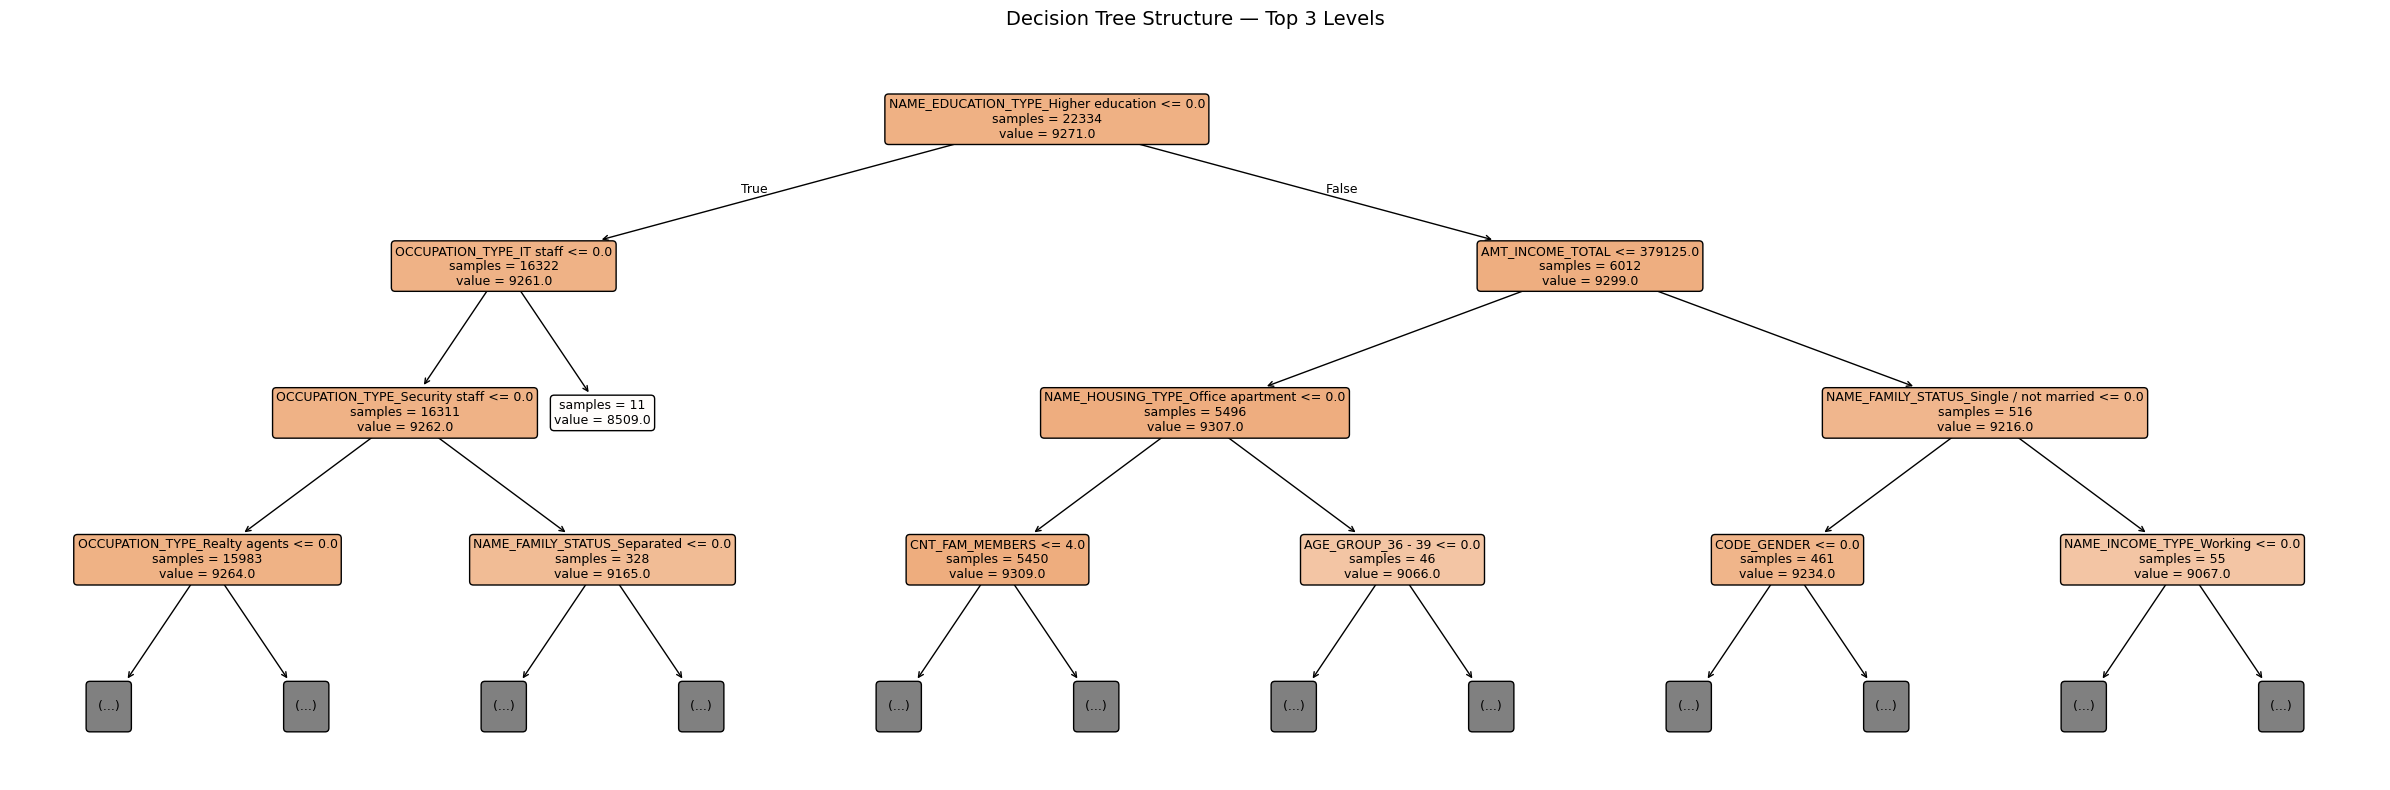

In [76]:
# Visualize the top 3 levels of the trained Decision Tree
plt.figure(figsize=(24, 8))
plot_tree(
    dt,
    max_depth=3,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    precision=0
)
plt.title('Decision Tree Structure — Top 3 Levels', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<br>

# **Model 3: Random Forest Regressor**

#### **Observation regarding `Random Forest Regressor`**
- The Random Forest model performs **better than the Decision Tree**, but the predictive power is still **very low (Test R² = 0.031)**, meaning the model explains only about **3% of the variance** in scores.
- **AMT_INCOME_TOTAL and AGE** are the most important features influencing the predicted score, followed by **family size and asset ownership variables**.
- The **RMSE (~569)** indicates that predictions differ from the actual scores by about **569 points on average**.
- Cross-validation results (**CV R² ≈ 0.027**) confirm that the model performance is **consistently weak across different data splits**.
- The residual plots show that **prediction errors are centered around zero**, but the wide spread indicates **limited prediction accuracy**.

## **3.1 Train the Random Forest Regressor**

In [77]:
# Initialize the Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train, y_train)

# Display basic model information
print('Random Forest training complete!')
print(f'Trees trained: {rf.n_estimators}')
print(f'Features used: {rf.n_features_in_}')

Random Forest training complete!
Trees trained: 300
Features used: 52


<br>

## **3.2 Evaluate the Random Forest (R² and RMSE)**

In [78]:
# Generate predictions for training and testing data
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

# Calculate R² scores
rf_r2_train = r2_score(y_train, y_pred_rf_train)
rf_r2_test = r2_score(y_test, y_pred_rf_test)

# Calculate RMSE values
rf_rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))

# Perform 5-fold cross-validation using R²
rf_cv_r2 = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

# Perform 5-fold cross-validation using RMSE
rf_cv_rmse = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convert negative RMSE values to positive
rf_cv_rmse = -rf_cv_rmse

# Display model performance summary
print('=' * 55)
print('        RANDOM FOREST — PERFORMANCE SUMMARY')
print('=' * 55)
print(f'{'Metric':<20}{'Train':>15}{'Test':>15}')
print('-' * 55)
print(f'{'R²':<20}{rf_r2_train:>15.4f}{rf_r2_test:>15.4f}')
print(f'{'RMSE':<20}{rf_rmse_train:>15.2f}{rf_rmse_test:>15.2f}')
print('=' * 55)

# Display cross-validation results
print(f'5-Fold CV R²: {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}')
print(f'5-Fold CV RMSE: {rf_cv_rmse.mean():.2f} ± {rf_cv_rmse.std():.2f}')

        RANDOM FOREST — PERFORMANCE SUMMARY
Metric                        Train           Test
-------------------------------------------------------
R²                           0.1189         0.0272
RMSE                         545.76         570.13
5-Fold CV R²: 0.0246 ± 0.0035
5-Fold CV RMSE: 574.14 ± 4.96


<br>

## **3.3 Random Forest Diagnostic Plots**

In [79]:
# Create diagnostic plots for the Random Forest model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [80]:
# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.25, s=8, color='steelblue')
rng = [y_test.min(), y_test.max()]
axes[0].plot(rng, rng, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Random Forest\nActual vs Predicted (Test R² = {rf_r2_test:.4f})')
axes[0].legend(fontsize=9)

In [81]:
# 2. Residual Distribution
rf_residuals = y_test - y_pred_rf_test
axes[1].hist(rf_residuals, bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(
    f'Random Forest — Residual Distribution\n'
    f'Mean = {rf_residuals.mean():.1f} | Std = {rf_residuals.std():.1f}'
)

Text(0.5, 1.0, 'Random Forest — Residual Distribution\nMean = -7.1 | Std = 570.1')

In [82]:
# 3. Residuals vs Predicted
axes[2].scatter(y_pred_rf_test, rf_residuals, alpha=0.25, s=8, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--', lw=1.5)
axes[2].set_xlabel('Predicted Score')
axes[2].set_ylabel('Residual')
axes[2].set_title('Random Forest — Residuals vs Predicted')

Text(0.5, 1.0, 'Random Forest — Residuals vs Predicted')

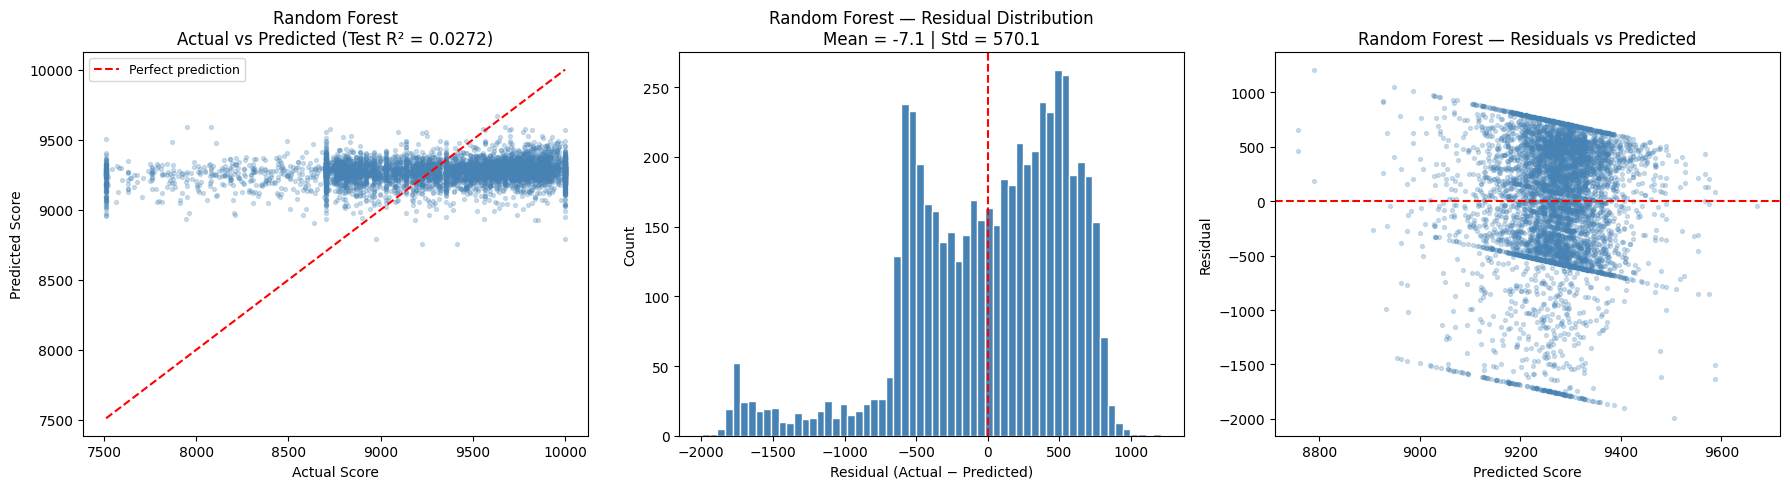

In [83]:
# Display the plots
plt.tight_layout()
plt.show()

<br>

## **3.4 Random Forest Feature Importances**

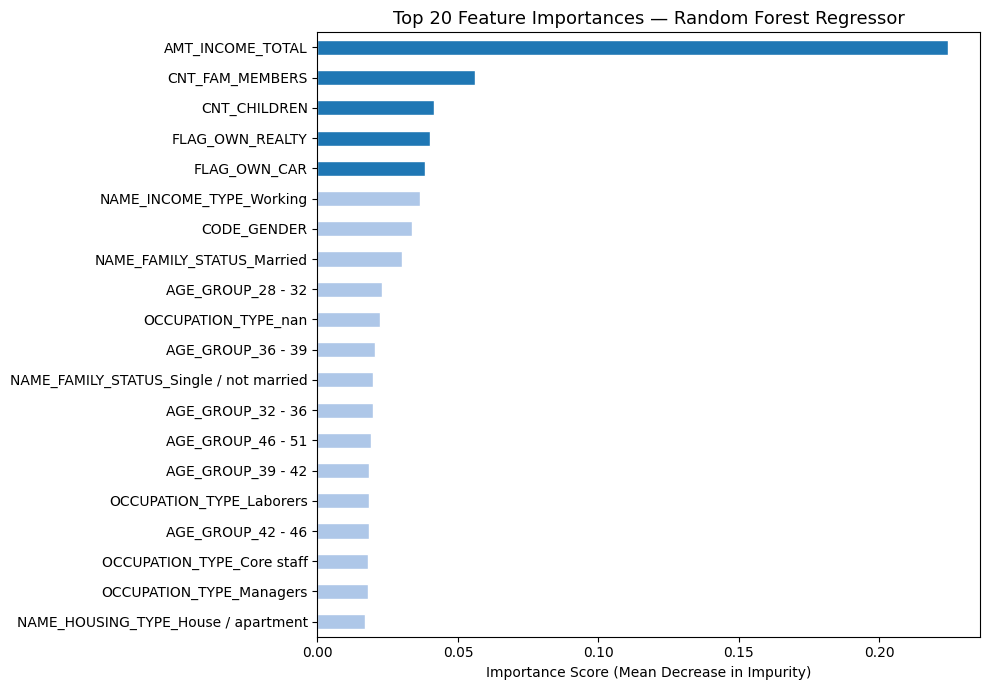

Top 10 features (Random Forest):
AMT_INCOME_TOTAL              0.2246
CNT_FAM_MEMBERS               0.0561
CNT_CHILDREN                  0.0416
FLAG_OWN_REALTY               0.0401
FLAG_OWN_CAR                  0.0382
NAME_INCOME_TYPE_Working      0.0365
CODE_GENDER                   0.0335
NAME_FAMILY_STATUS_Married    0.0301
AGE_GROUP_28 - 32             0.0229
OCCUPATION_TYPE_nan           0.0221


In [84]:
# Calculate feature importance scores from the Random Forest model
rf_imp = pd.Series(rf.feature_importances_, index=X.columns)

# Select the top 20 most important features
rf_top20 = rf_imp.sort_values(ascending=False).head(20)

# Create a horizontal bar chart for the top 20 feature importances
plt.figure(figsize=(10, 7))
colors_rf = ['#1f77b4' if i < 5 else '#aec7e8' for i in range(len(rf_top20))]
rf_top20.sort_values().plot(kind='barh', color=colors_rf[::-1], edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest Regressor', fontsize=13)
plt.xlabel('Importance Score (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

# Display the top 10 most important features and their scores
print('Top 10 features (Random Forest):')
print(rf_top20.head(10).round(4).to_string())

<br>

# **Model Comparison: Decision Tree vs Random Forest**

#### **Observation regarding `Model Comparison (Decision Tree vs Random Forest)`**
- The **Random Forest model performs better overall**, with a higher **Test R² (0.0310 vs -0.0038)** and a lower **Test RMSE (569.04 vs 579.17)** compared to the Decision Tree.
- Cross-validation results also show **more stable performance for Random Forest** (CV R² = 0.0273) while the Decision Tree performs poorly (CV R² = -0.0141).
- The most influential predictors for score in both models are **AMT_INCOME_TOTAL, AGE, and CNT_FAM_MEMBERS**.
- Although Random Forest improves performance compared to the Decision Tree, the **overall predictive power remains low**.

## **6.1 Side-by-Side Metrics Table**

In [85]:
# Create a summary table to compare Decision Tree and Random Forest model performance
comparison = pd.DataFrame({

    'Decision Tree': {
        'Train R²':       round(dt_r2_train, 4),
        'Test R²':        round(dt_r2_test, 4),
        'Train RMSE':     round(dt_rmse_train, 2),
        'Test RMSE':      round(dt_rmse_test, 2),
        'CV R² (mean)':   round(dt_cv_r2.mean(), 4),
        'CV R² (std)':    round(dt_cv_r2.std(), 4),
        'CV RMSE (mean)': round((-dt_cv_rmse).mean(), 2),
        'CV RMSE (std)':  round((-dt_cv_rmse).std(), 2),
    },

    'Random Forest': {
        'Train R²':       round(rf_r2_train, 4),
        'Test R²':        round(rf_r2_test, 4),
        'Train RMSE':     round(rf_rmse_train, 2),
        'Test RMSE':      round(rf_rmse_test, 2),
        'CV R² (mean)':   round(rf_cv_r2.mean(), 4),
        'CV R² (std)':    round(rf_cv_r2.std(), 4),
        'CV RMSE (mean)': round((-rf_cv_rmse).mean(), 2),
        'CV RMSE (std)':  round((-rf_cv_rmse).std(), 2),
    }

})

# Display the model comparison results
print('=' * 55)
print('MODEL COMPARISON SUMMARY')
print('=' * 55)
print(comparison.to_string())
print()

MODEL COMPARISON SUMMARY
                Decision Tree  Random Forest
Train R²               0.0325         0.1189
Test R²               -0.0058         0.0272
Train RMSE           571.8600       545.7600
Test RMSE            579.7500       570.1300
CV R² (mean)          -0.0162         0.0246
CV R² (std)            0.0034         0.0035
CV RMSE (mean)      -586.0400      -574.1400
CV RMSE (std)          5.3700         4.9600



In [86]:
# Compare Decision Tree and Random Forest performance using Test R² and Test RMSE

# Select the model with the higher Test R²
r2_winner = 'Random Forest' if rf_r2_test > dt_r2_test else 'Decision Tree'

# Select the model with the lower Test RMSE
rmse_winner = 'Random Forest' if rf_rmse_test < dt_rmse_test else 'Decision Tree'

# Print the better model for each evaluation metric
print(f'Model with higher Test R²: {r2_winner}')
print(f'Model with lower Test RMSE: {rmse_winner}')

Model with higher Test R²: Random Forest
Model with lower Test RMSE: Random Forest


<br>

## **6.2 Visual Comparison**

In [87]:
# Create subplots to compare model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [88]:
# Define model names and colors
models = ['Decision Tree', 'Random Forest']
colors = ['darkorange', 'steelblue']

In [89]:
# 1. Compare Train vs Test R² for Decision Tree and Random Forest

# Prepare R² values for train and test sets
r2_train_vals = [dt_r2_train, rf_r2_train]
r2_test_vals  = [dt_r2_test,  rf_r2_test]

# Define bar positions and width
x = np.arange(len(models))
w = 0.35

# Plot bar charts for Train and Test R²
axes[0].bar(x - w/2, r2_train_vals, width=w, label='Train', color=colors, alpha=0.5, edgecolor='white')
axes[0].bar(x + w/2, r2_test_vals,  width=w, label='Test',  color=colors, alpha=1.0, edgecolor='white')

# Configure axis labels and title
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Train vs Test')
axes[0].legend()

# Add a reference line at zero
axes[0].axhline(0, color='black', lw=0.8, linestyle='--')

# Annotate each bar with its value
for i, (tr, te) in enumerate(zip(r2_train_vals, r2_test_vals)):
    axes[0].text(i - w/2, tr + 0.001, f'{tr:.4f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + w/2, te + 0.001, f'{te:.4f}', ha='center', va='bottom', fontsize=8)

In [90]:
# 2. Compare Train vs Test RMSE values for both models

# Prepare RMSE values for train and test sets
rmse_train_vals = [dt_rmse_train, rf_rmse_train]
rmse_test_vals  = [dt_rmse_test,  rf_rmse_test]

# Plot bar charts for Train and Test RMSE
axes[1].bar(x - w/2, rmse_train_vals, width=w, label='Train', color=colors, alpha=0.5, edgecolor='white')
axes[1].bar(x + w/2, rmse_test_vals,  width=w, label='Test',  color=colors, alpha=1.0, edgecolor='white')

# Configure axis labels and title
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylabel('RMSE (score points)')
axes[1].set_title('RMSE — Train vs Test (Lower is Better)')
axes[1].legend()

# Annotate each bar with its value
for i, (tr, te) in enumerate(zip(rmse_train_vals, rmse_test_vals)):
    axes[1].text(i - w/2, tr + 1, f'{tr:.1f}', ha='center', va='bottom', fontsize=8)
    axes[1].text(i + w/2, te + 1, f'{te:.1f}', ha='center', va='bottom', fontsize=8)

In [91]:
# 3. Compare Actual vs Predicted values for both models on the test dataset

# Plot predictions from Decision Tree and Random Forest
axes[2].scatter(y_test, y_pred_dt_test, alpha=0.15, s=6, color='darkorange', label='Decision Tree')
axes[2].scatter(y_test, y_pred_rf_test, alpha=0.15, s=6, color='steelblue', label='Random Forest')

# Add a diagonal line representing perfect predictions
rng = [y_test.min(), y_test.max()]
axes[2].plot(rng, rng, 'r--', lw=1.5, label='Perfect prediction')

# Configure axis labels and title
axes[2].set_xlabel('Actual Score')
axes[2].set_ylabel('Predicted Score')
axes[2].set_title('Actual vs Predicted — Both Models (Test Set)')

# Display legend
axes[2].legend(fontsize=9)

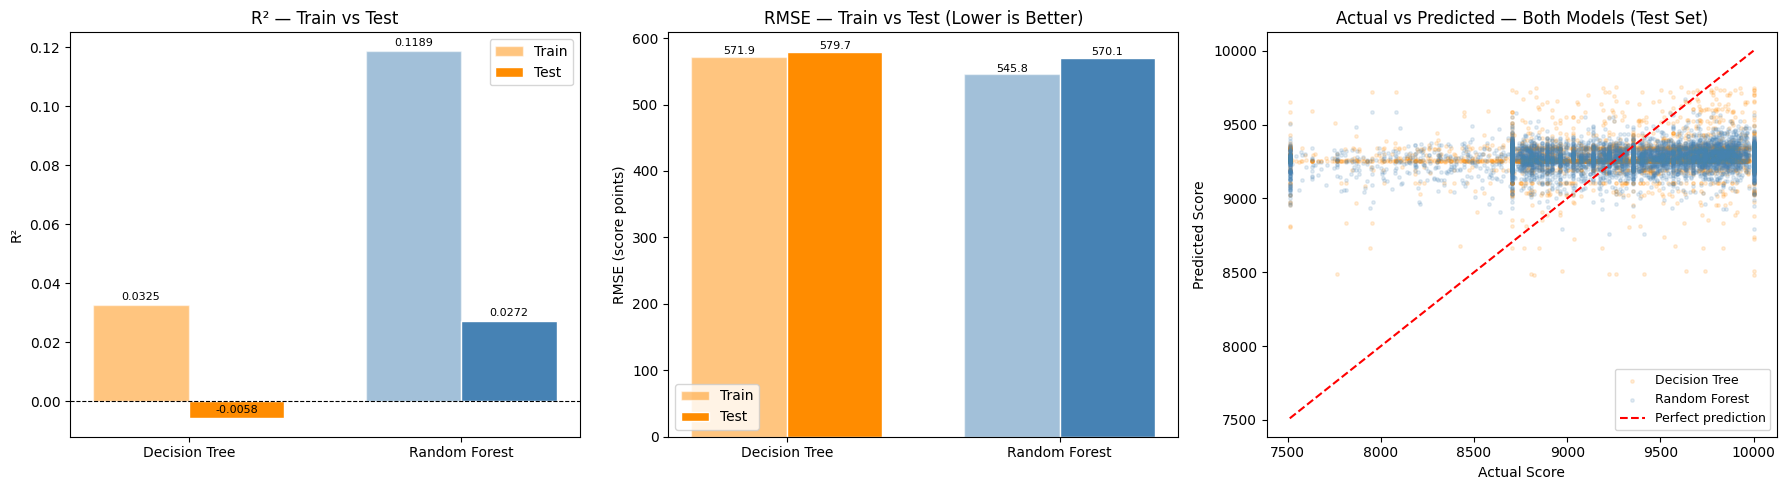

In [92]:
# Display the plots
plt.tight_layout()
plt.show()

<br>

## **6.3 Feature Importance Comparison (Top 15)**

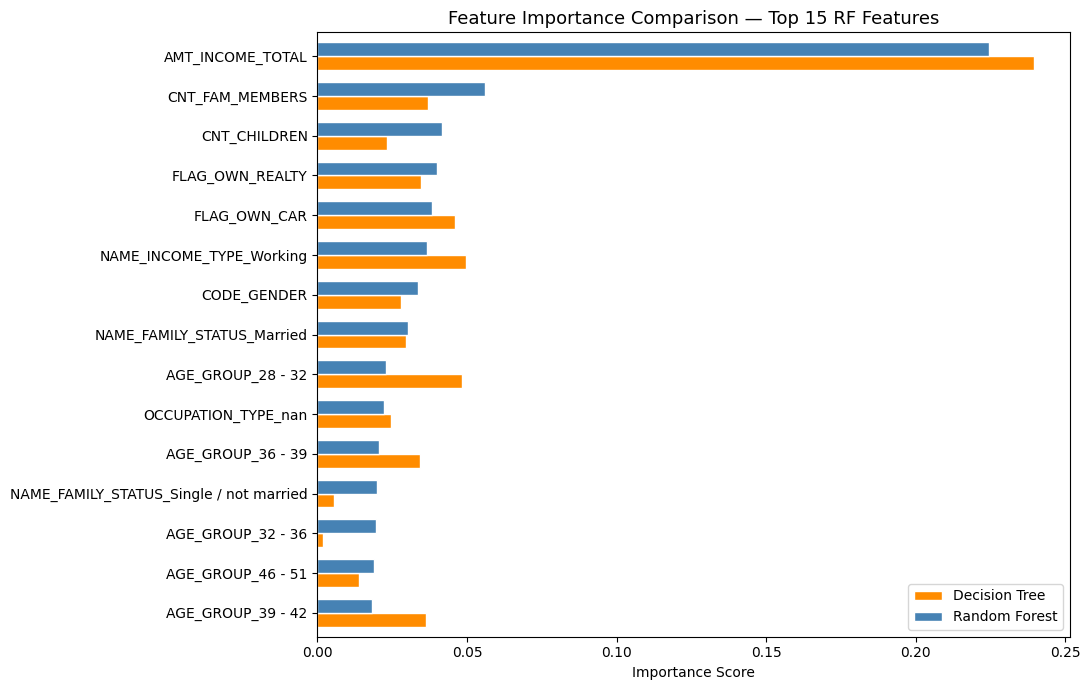

Side-by-side importance (sorted by Random Forest):
                                         Decision Tree  Random Forest
AMT_INCOME_TOTAL                                0.2396         0.2246
CNT_FAM_MEMBERS                                 0.0369         0.0561
CNT_CHILDREN                                    0.0234         0.0416
FLAG_OWN_REALTY                                 0.0346         0.0401
FLAG_OWN_CAR                                    0.0459         0.0382
NAME_INCOME_TYPE_Working                        0.0498         0.0365
CODE_GENDER                                     0.0280         0.0335
NAME_FAMILY_STATUS_Married                      0.0297         0.0301
AGE_GROUP_28 - 32                               0.0483         0.0229
OCCUPATION_TYPE_nan                             0.0245         0.0221
AGE_GROUP_36 - 39                               0.0341         0.0206
NAME_FAMILY_STATUS_Single / not married         0.0056         0.0198
AGE_GROUP_32 - 36                      

In [93]:
# Select the top 15 features based on Random Forest importance
top15_features = rf_imp.sort_values(ascending=False).head(15).index.tolist()

# Create a DataFrame to compare feature importance between Decision Tree and Random Forest
imp_compare = pd.DataFrame({
    'Decision Tree': dt_imp[top15_features],
    'Random Forest': rf_imp[top15_features]
}).sort_values('Random Forest', ascending=True)

# Plot horizontal bar chart to compare feature importance
imp_compare.plot(
    kind='barh',
    figsize=(11, 7),
    color=['darkorange', 'steelblue'],
    edgecolor='white',
    width=0.7
)

# Configure chart title and labels
plt.title('Feature Importance Comparison — Top 15 RF Features', fontsize=13)
plt.xlabel('Importance Score')
plt.legend(loc='lower right')

# Adjust layout and display plot
plt.tight_layout()
plt.show()

# Print side-by-side feature importance values
print('Side-by-side importance (sorted by Random Forest):')
print(imp_compare.sort_values('Random Forest', ascending=False).round(4).to_string())